# Clasificación no supervisada de dígitos con K‑Means

**Objetivo:** Aplicar el algoritmo K‑Means al conjunto de dígitos manuscritos `digits` de scikit‑learn.  
Se exploran distintos valores de K (10, 8, 6, 4) y se comparan los grupos resultantes con las etiquetas reales para entender cómo agrupa el algoritmo sin supervisión.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans

## Paso 2: Carga el dataset

In [2]:
digits = load_digits()
data = digits.data          # Imágenes en forma plana (1797, 64)
labels = digits.target      # Números reales (0-9) para evaluar después

print(f"Datos cargados: {data.shape[0]} muestras, {data.shape[1]} píxeles cada una.")

Datos cargados: 1797 muestras, 64 píxeles cada una.


## Paso 3: Analiza los datos

In [3]:
# Forma de la matriz de datos
print("Dimensiones de data:", data.shape)   # (1797, 64)

# Una muestra individual
sample_num = 10
print(f"Vector de píxeles de la muestra {sample_num}:")
print(data[sample_num, :])

Dimensiones de data: (1797, 64)
Vector de píxeles de la muestra 10:
[ 0.  0.  1.  9. 15. 11.  0.  0.  0.  0. 11. 16.  8. 14.  6.  0.  0.  2.
 16. 10.  0.  9.  9.  0.  0.  1. 16.  4.  0.  8.  8.  0.  0.  4. 16.  4.
  0.  8.  8.  0.  0.  1. 16.  5.  1. 11.  3.  0.  0.  0. 12. 12. 10. 10.
  0.  0.  0.  0.  1. 10. 13.  3.  0.  0.]


## Paso 4: Imprime una muestra como imagen

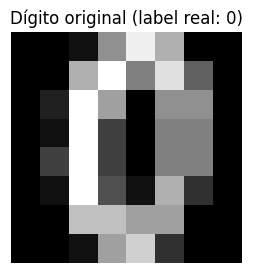

In [4]:
sample_num = 10
image = data[sample_num].reshape(8, 8)

plt.figure(figsize=(3, 3))
plt.imshow(image, cmap=plt.cm.gray)
plt.title(f"Dígito original (label real: {labels[sample_num]})")
plt.axis('off')
plt.show()

## Paso 5: Procesa las muestras

Invertimos los colores para que los dígitos tengan valores altos (claros) y el fondo sea oscuro. Esto ayuda a K‑Means a distinguir mejor las formas.

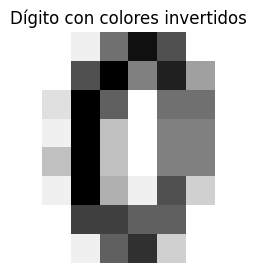

In [5]:
# Invertir los colores de todas las imágenes
data_inv = 255.0 - data

# Ver el efecto en la misma muestra
plt.figure(figsize=(3, 3))
plt.imshow(data_inv[sample_num].reshape(8, 8), cmap=plt.cm.gray)
plt.title("Dígito con colores invertidos")
plt.axis('off')
plt.show()

## Paso 6: Definir el modelo K‑Means

In [6]:
np.random.seed(1)
model = KMeans(n_clusters=10, init='random', n_init=10, random_state=1)
print("Modelo creado:", model)

Modelo creado: KMeans(init='random', n_clusters=10, n_init=10, random_state=1)


## Paso 7: Entrena el modelo

In [7]:
model.fit(data_inv)
print("Entrenamiento completado.")

Entrenamiento completado.


## Paso 8: Analiza el modelo entrenado

Se define una función que:
- Predice los clústeres.
- Muestra hasta 100 imágenes por grupo.
- Construye una tabla cruzada con los dígitos reales.
- Indica el número más frecuente en cada clúster.

In [8]:
def analizar_kmeans(k, max_imagenes=100):
    """Entrena KMeans con K clústeres, muestra gráficos y tabla de resultados."""
    # Reiniciar semilla y crear modelo
    np.random.seed(1)
    model = KMeans(n_clusters=k, init='random', n_init=10, random_state=1)
    model.fit(data_inv)
    clusters = model.predict(data_inv)

    # Mostrar imágenes por clúster
    for i in range(k):
        indices = np.where(clusters == i)[0]
        n_elem = len(indices)
        filas = int(np.ceil(n_elem / 10))
        plt.figure(figsize=(10, filas * 1.2))
        print(f"Clúster {i}: {n_elem} elementos")
        for pos in range(min(n_elem, max_imagenes)):
            plt.subplot(filas, 10, pos + 1)
            plt.imshow(data_inv[indices[pos]].reshape(8, 8), cmap='gray')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

    # Tabla cruzada
    tabla = pd.crosstab(clusters, labels,
                        rownames=['Clúster'], colnames=['Dígito real'])
    print(f"\nK = {k}: ¿Qué números aparecen en cada clúster?")
    print(tabla)

    print(f"\nNúmero más frecuente en cada clúster:")
    print(tabla.idxmax(axis=1))
    print("\n" + "="*60 + "\n")

## Análisis para K = 10

Clúster 0: 182 elementos


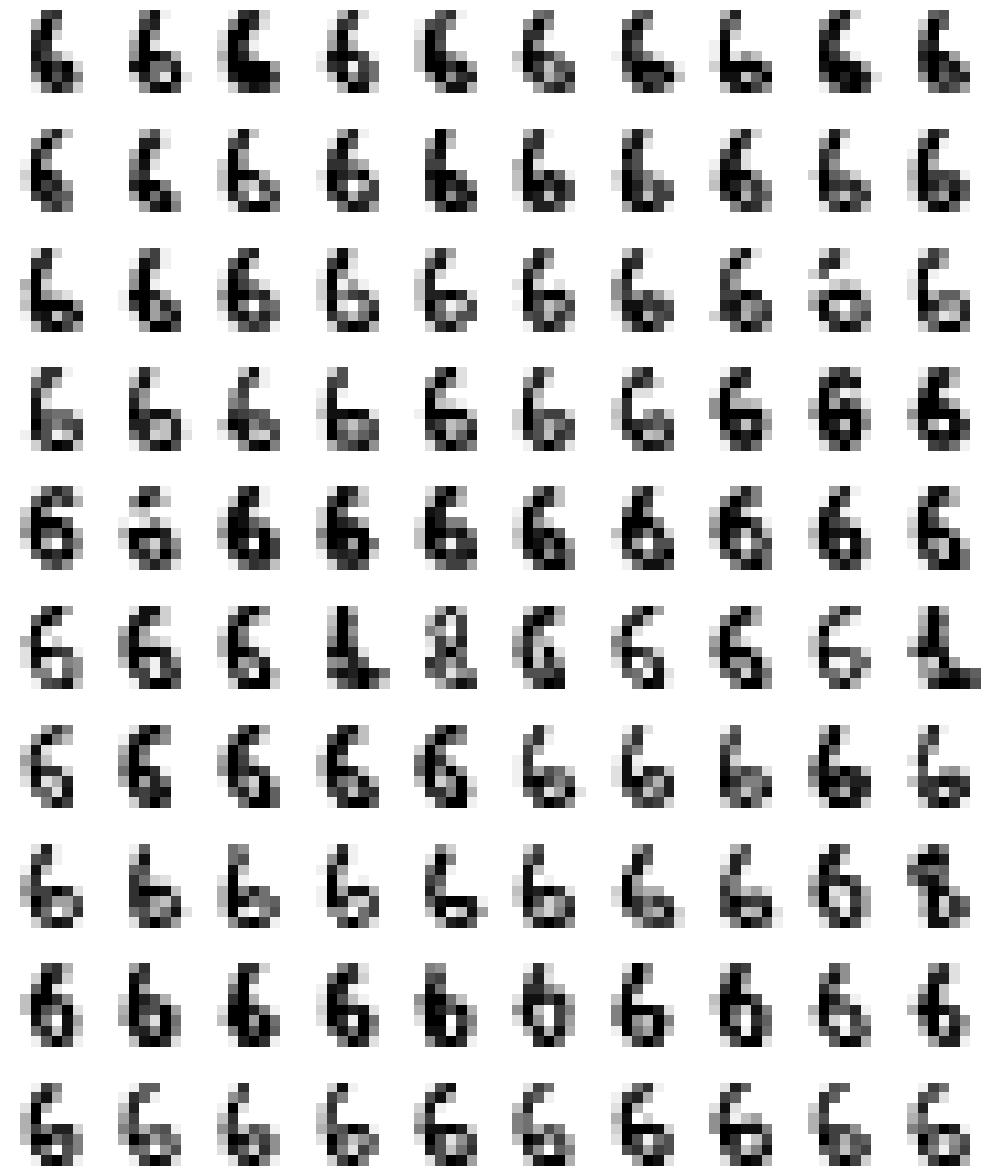

Clúster 1: 176 elementos


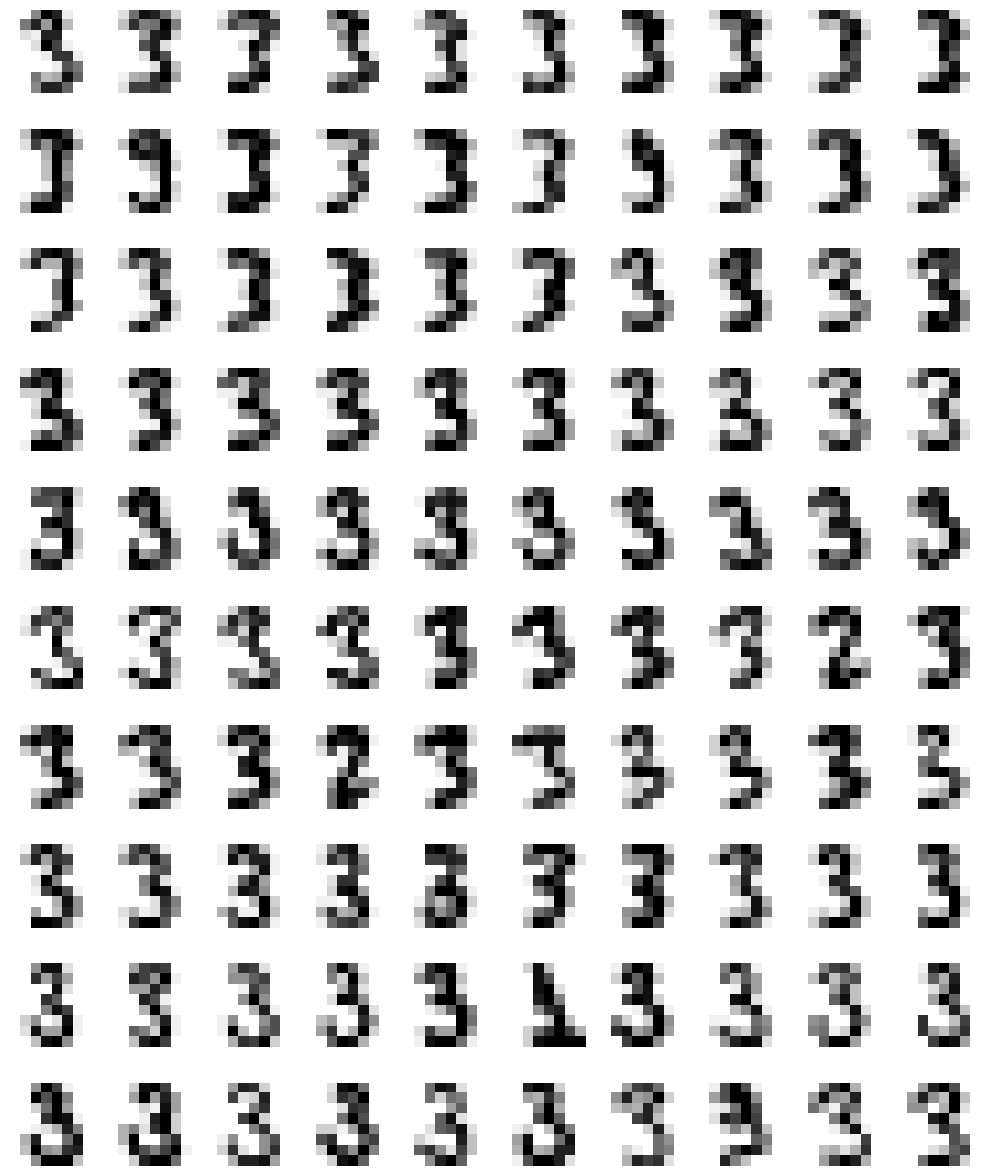

Clúster 2: 169 elementos


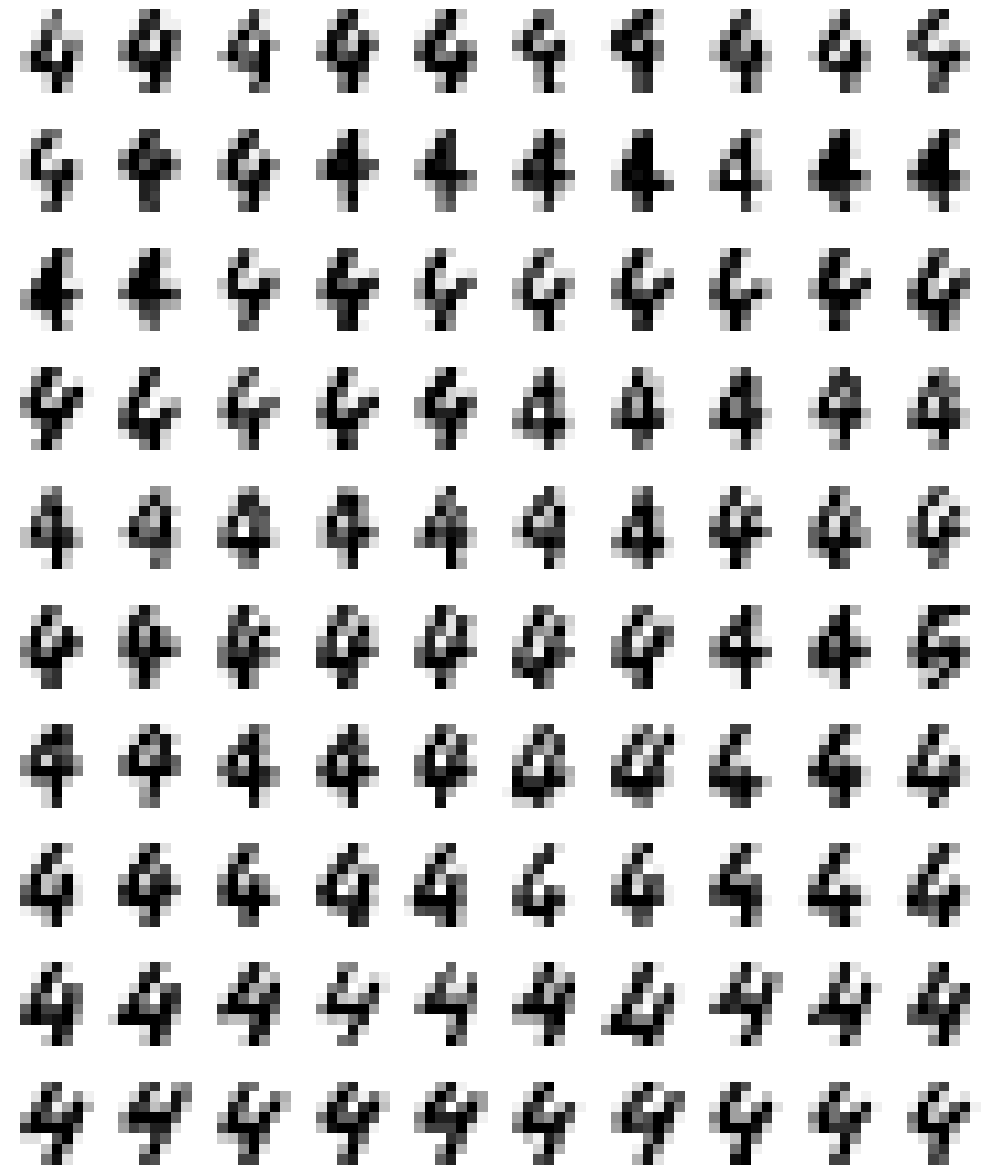

Clúster 3: 248 elementos


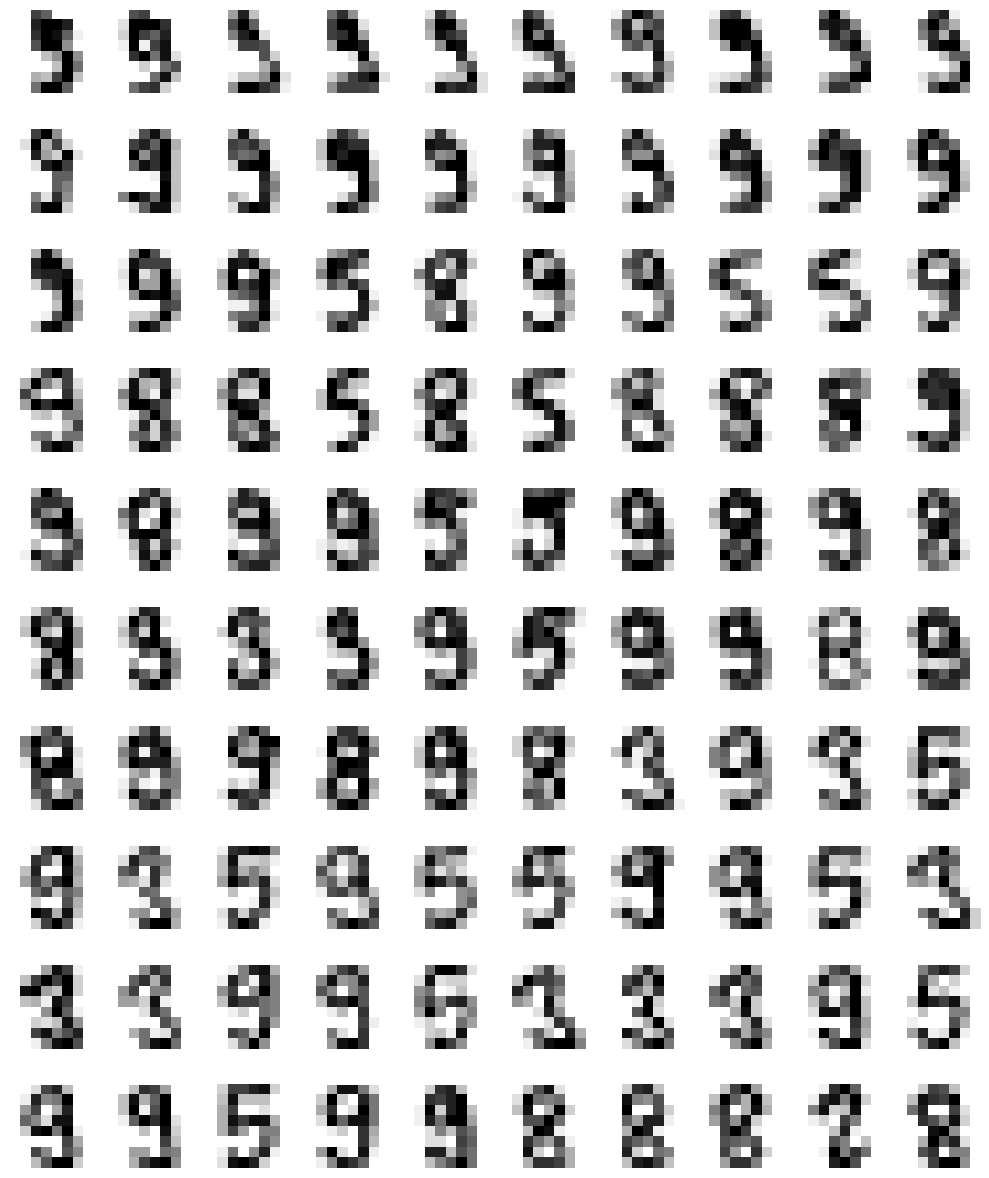

Clúster 4: 223 elementos


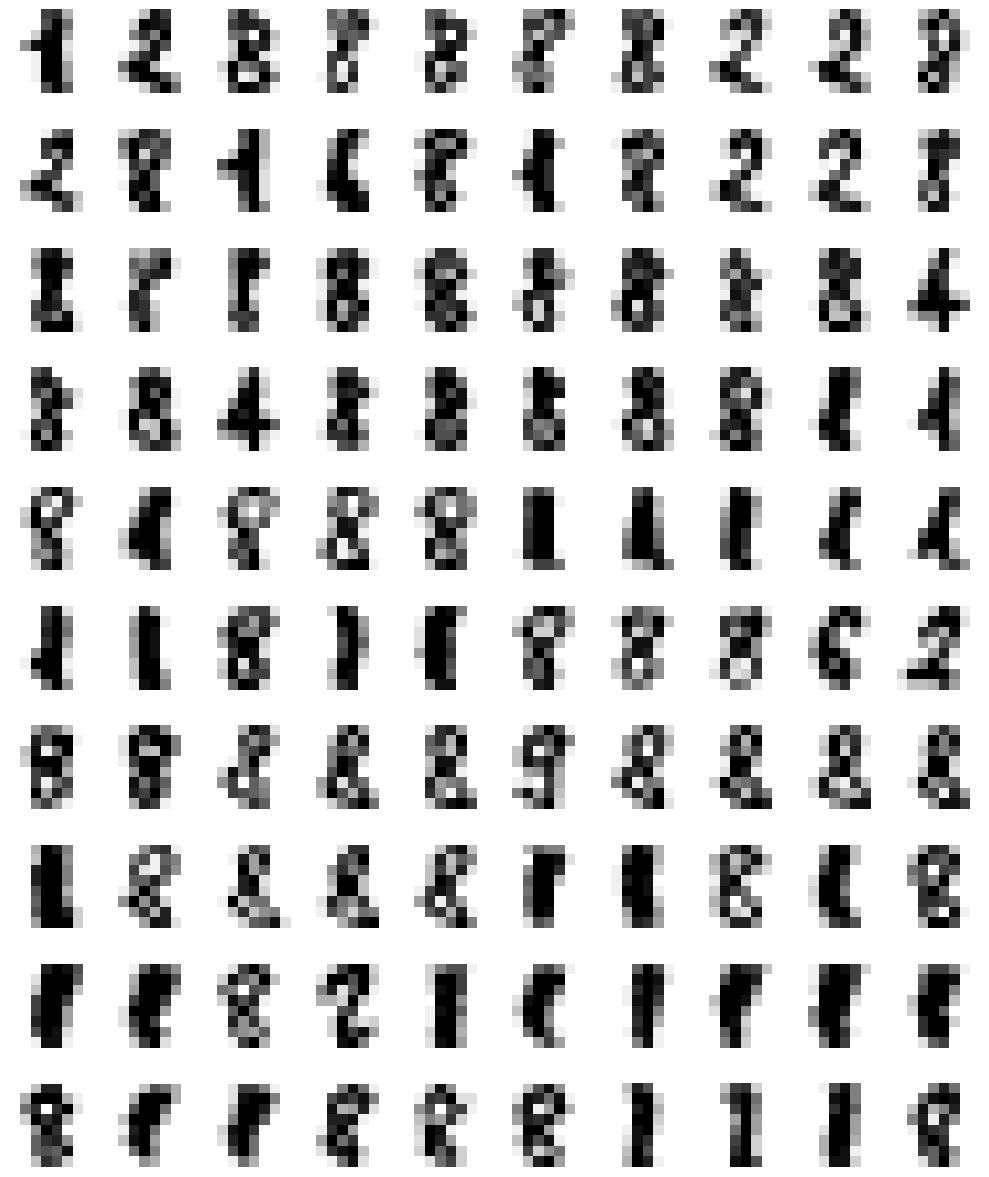

Clúster 5: 149 elementos


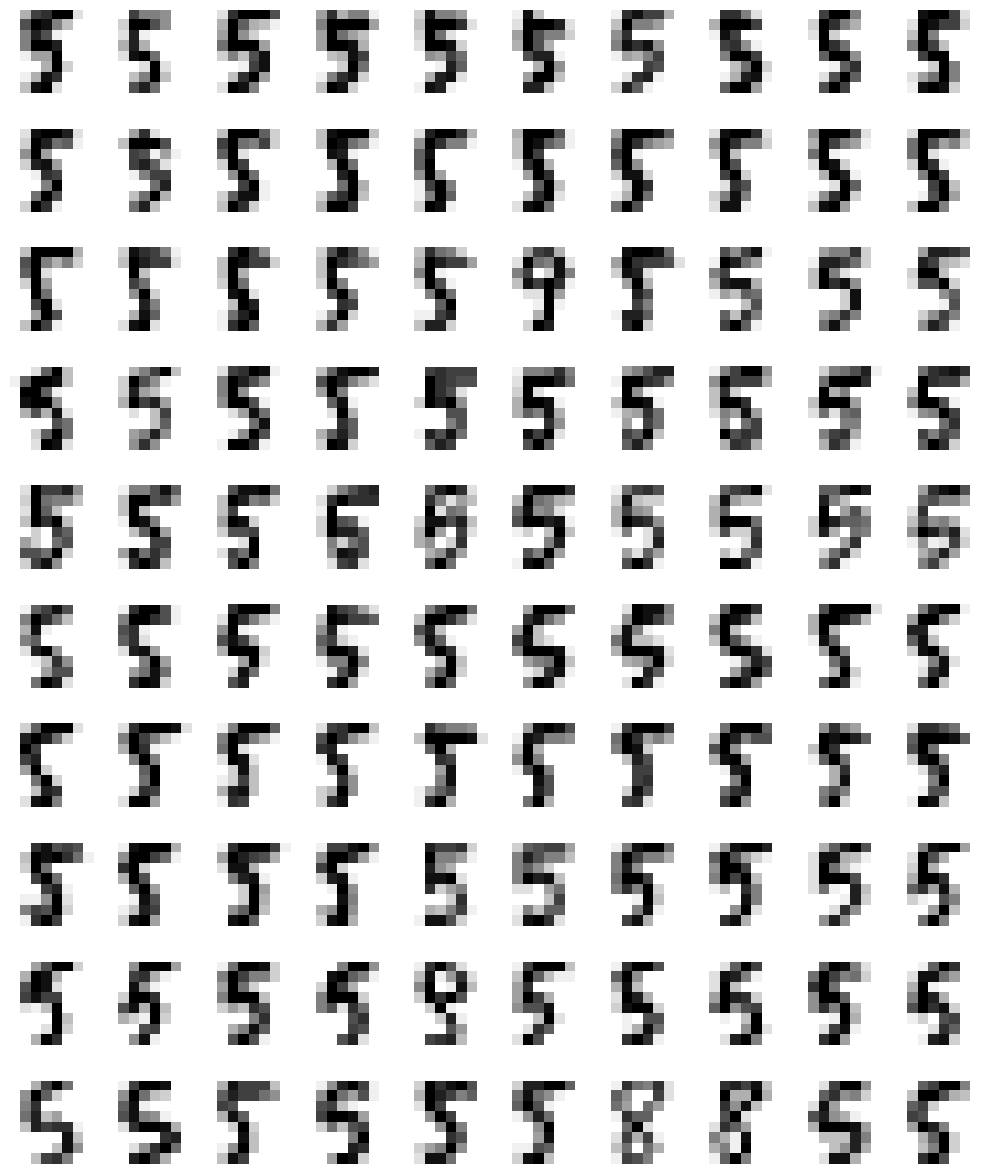

Clúster 6: 174 elementos


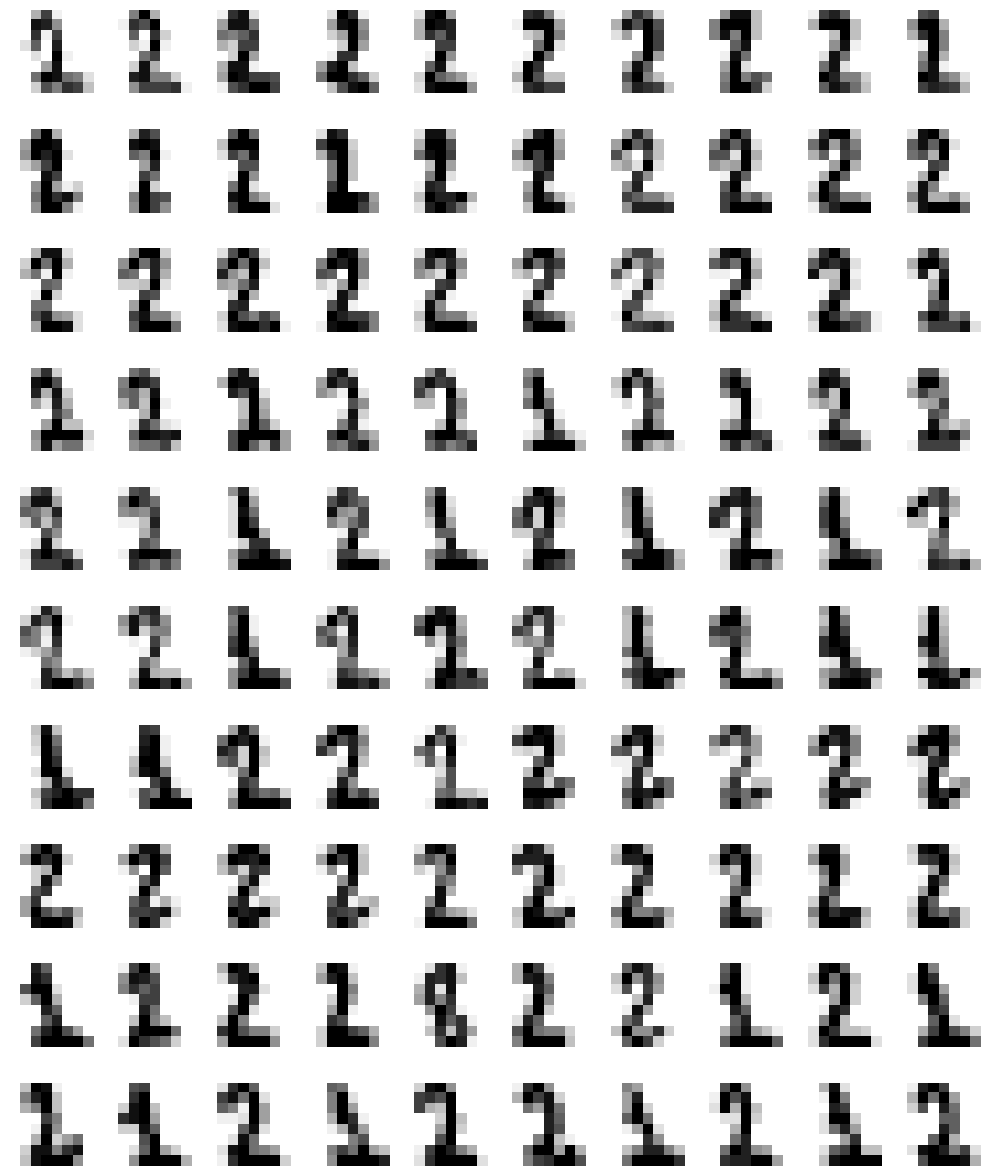

Clúster 7: 209 elementos


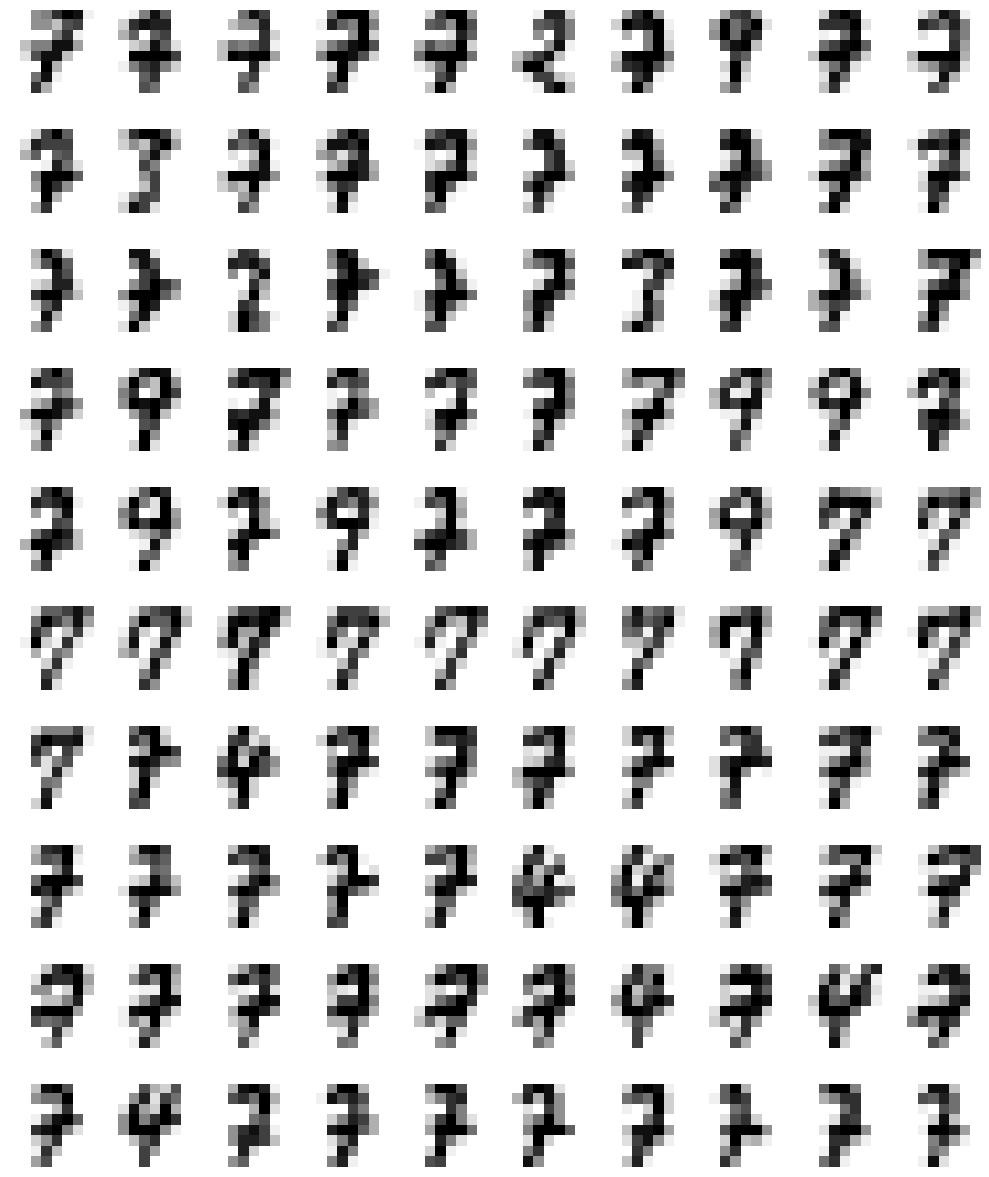

Clúster 8: 88 elementos


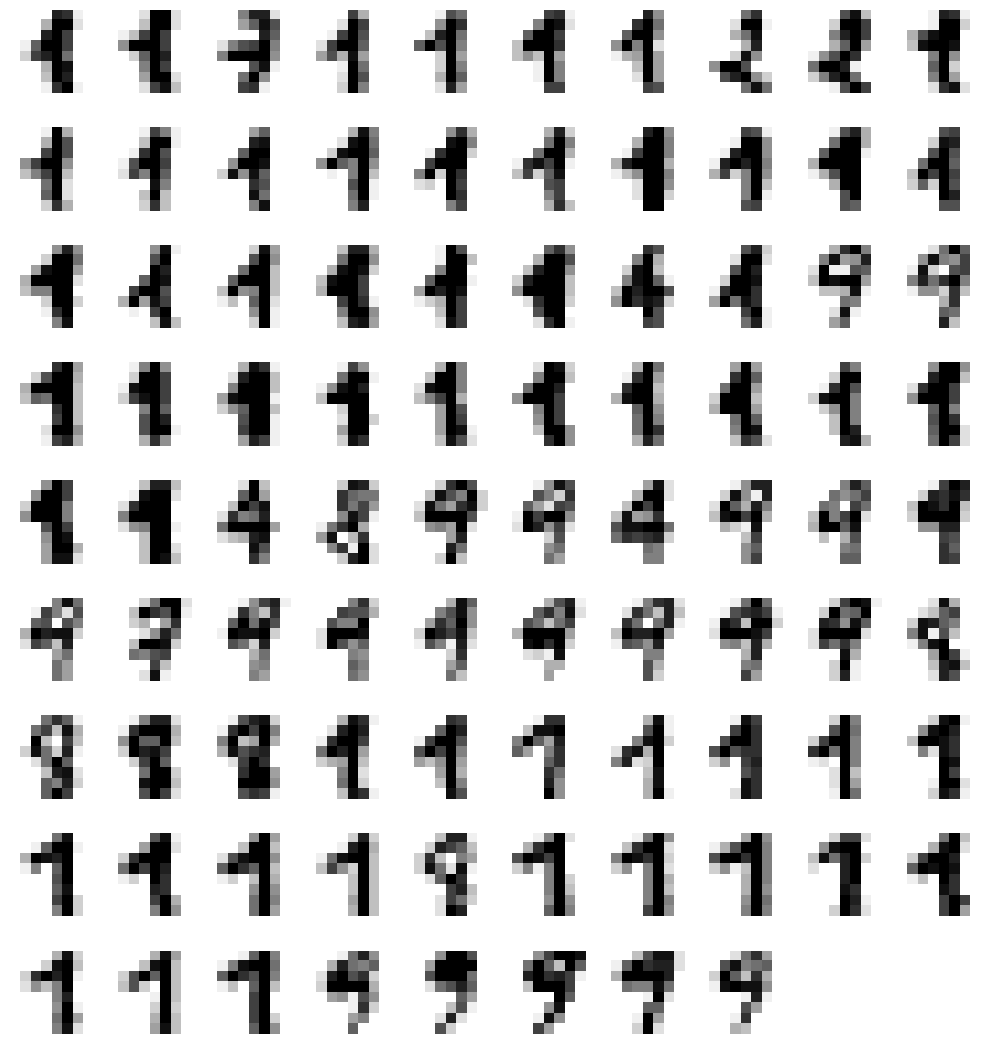

Clúster 9: 179 elementos


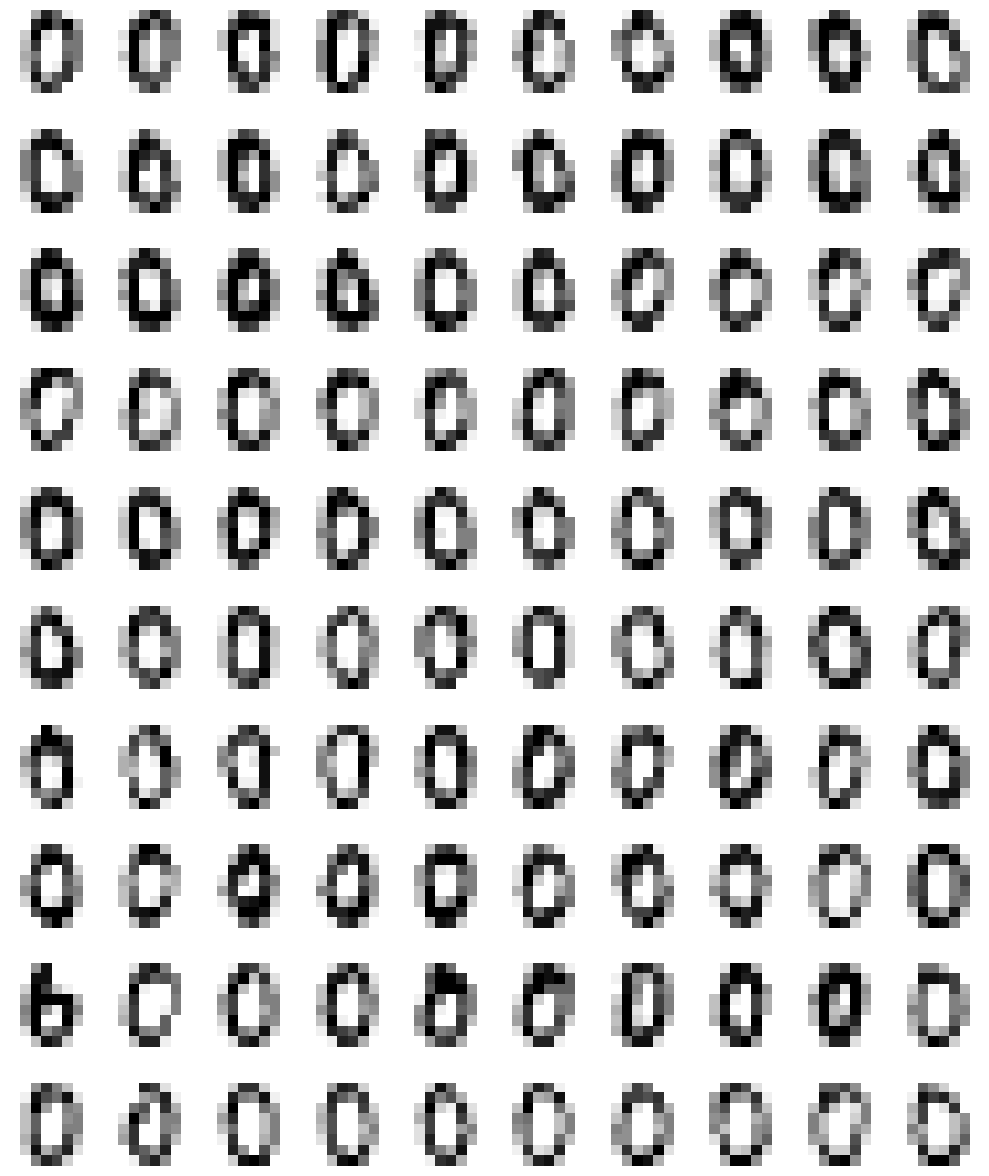


K = 10: ¿Qué números aparecen en cada clúster?
Dígito real    0   1    2    3    4    5    6    7    8    9
Clúster                                                     
0              0   2    0    0    0    1  177    0    2    0
1              0   1   13  154    0    0    0    0    2    6
2              1   0    0    0  166    2    0    0    0    0
3              0   0    2   13    0   43    0    0   51  139
4              0  99    8    7    2    0    3    2  101    1
5              0   1    0    2    0  136    0    0    4    6
6              0  24  147    0    0    0    0    0    3    0
7              0   0    4    7   10    0    0  175    5    8
8              0  55    2    0    3    0    0    2    6   20
9            177   0    1    0    0    0    1    0    0    0

Número más frecuente en cada clúster:
Clúster
0    6
1    3
2    4
3    9
4    8
5    5
6    2
7    7
8    1
9    0
dtype: int64




In [9]:
analizar_kmeans(k=10)

## Análisis para K = 8

Clúster 0: 181 elementos


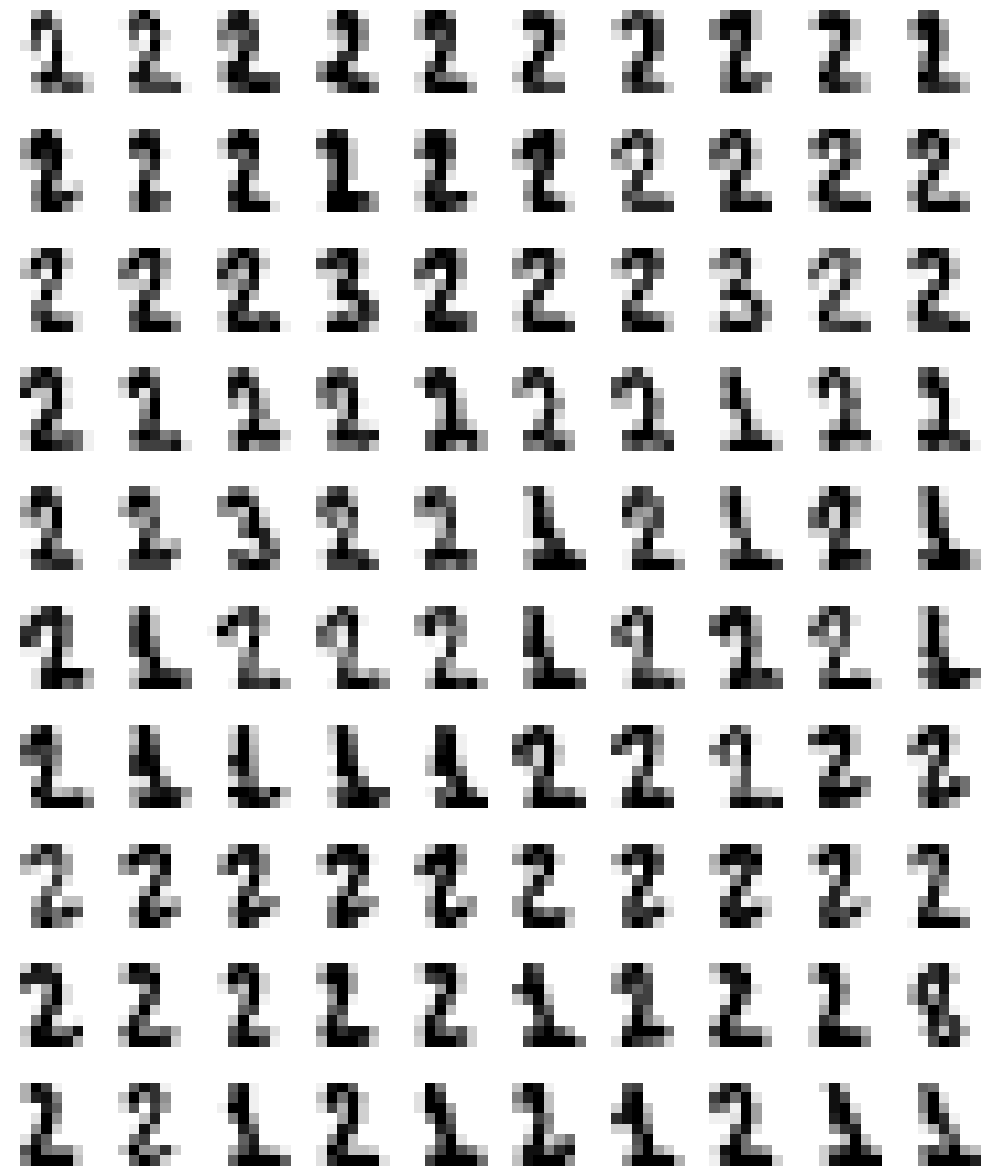

Clúster 1: 220 elementos


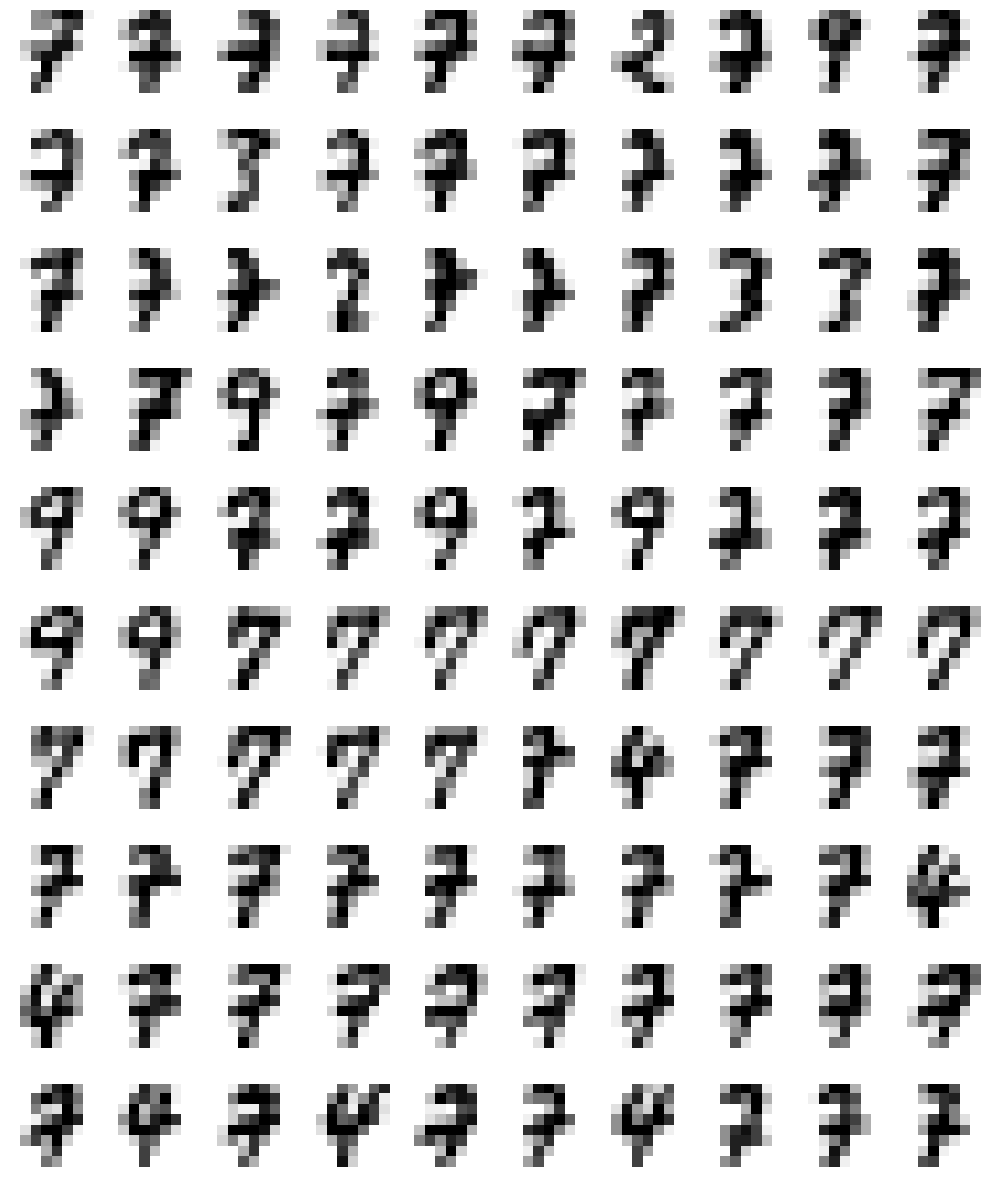

Clúster 2: 179 elementos


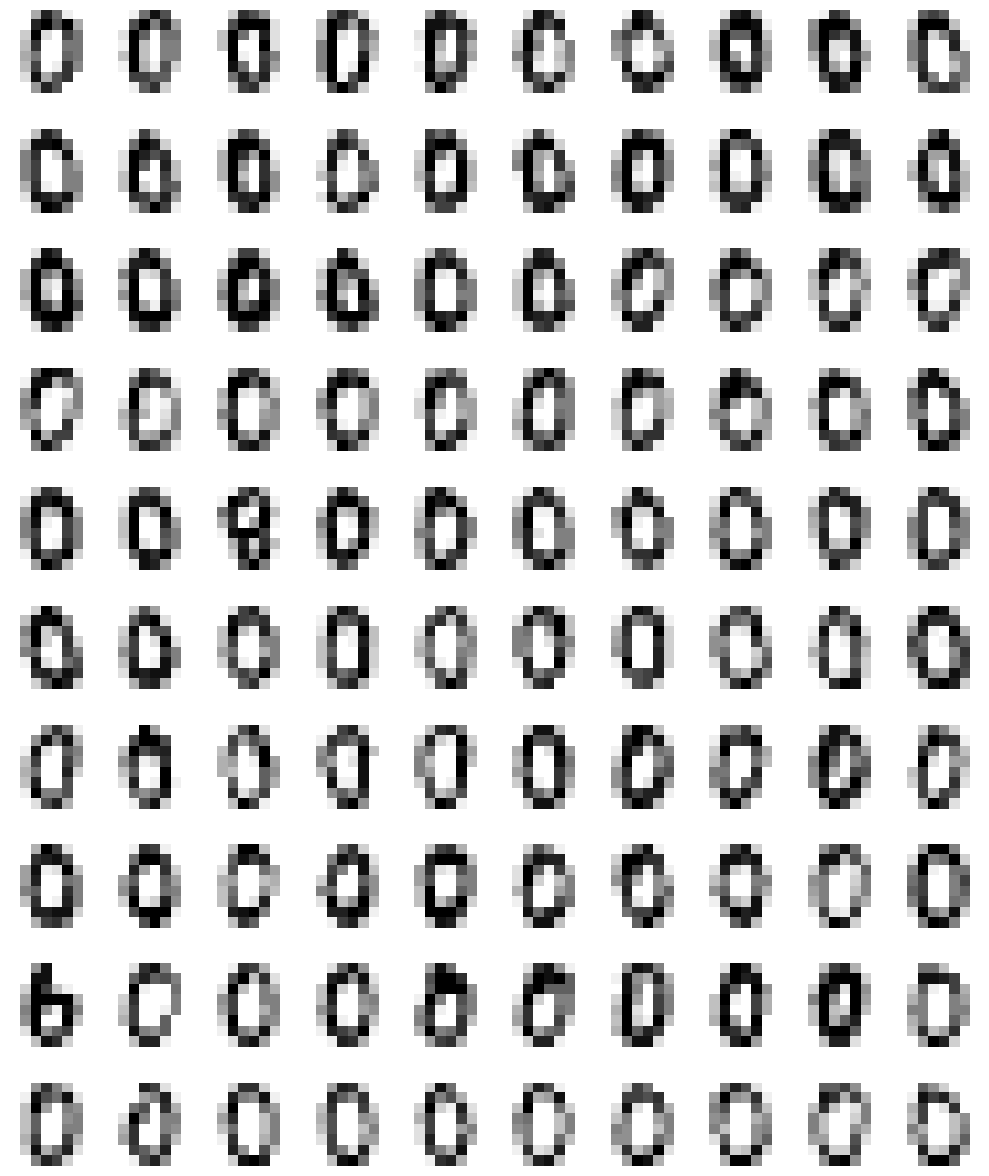

Clúster 3: 179 elementos


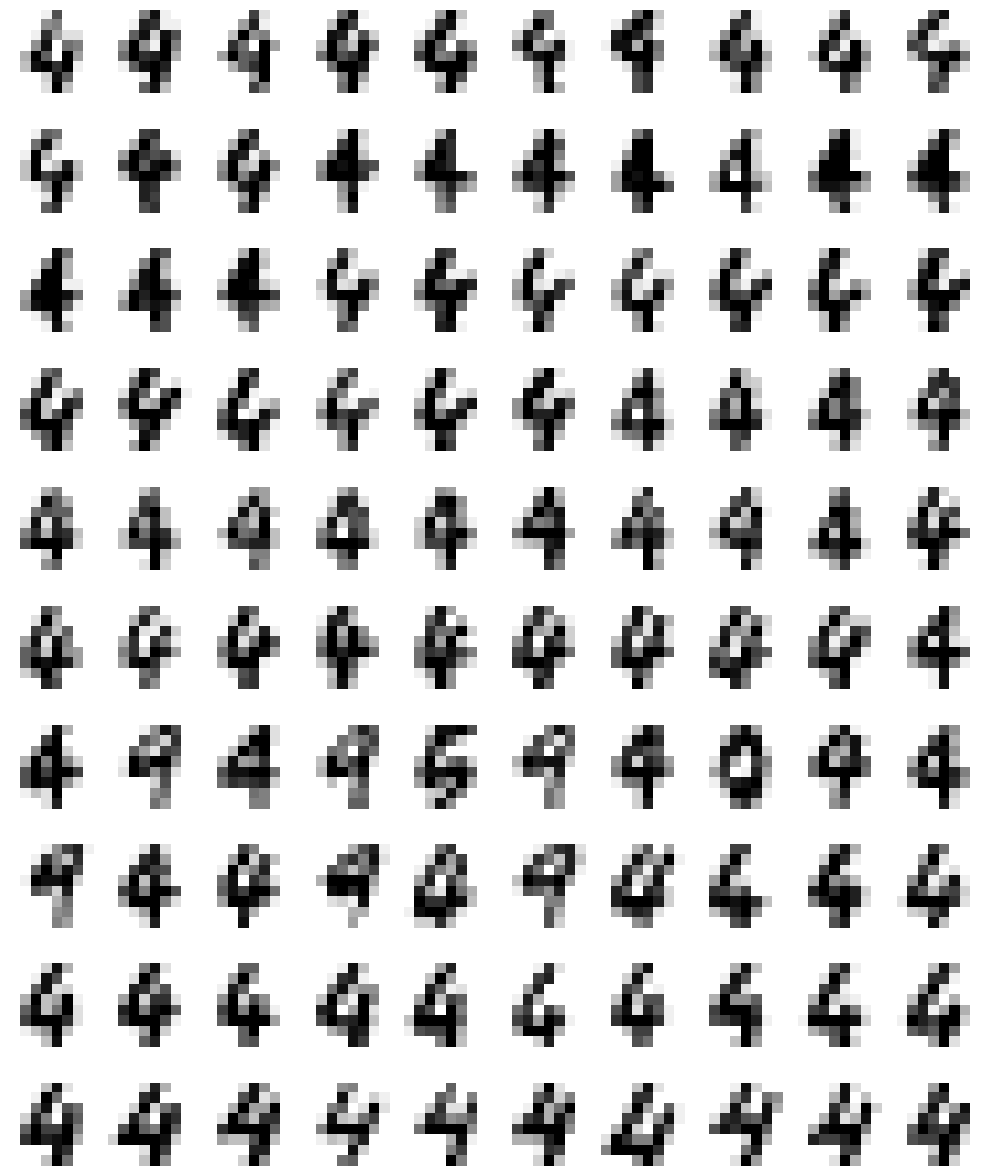

Clúster 4: 181 elementos


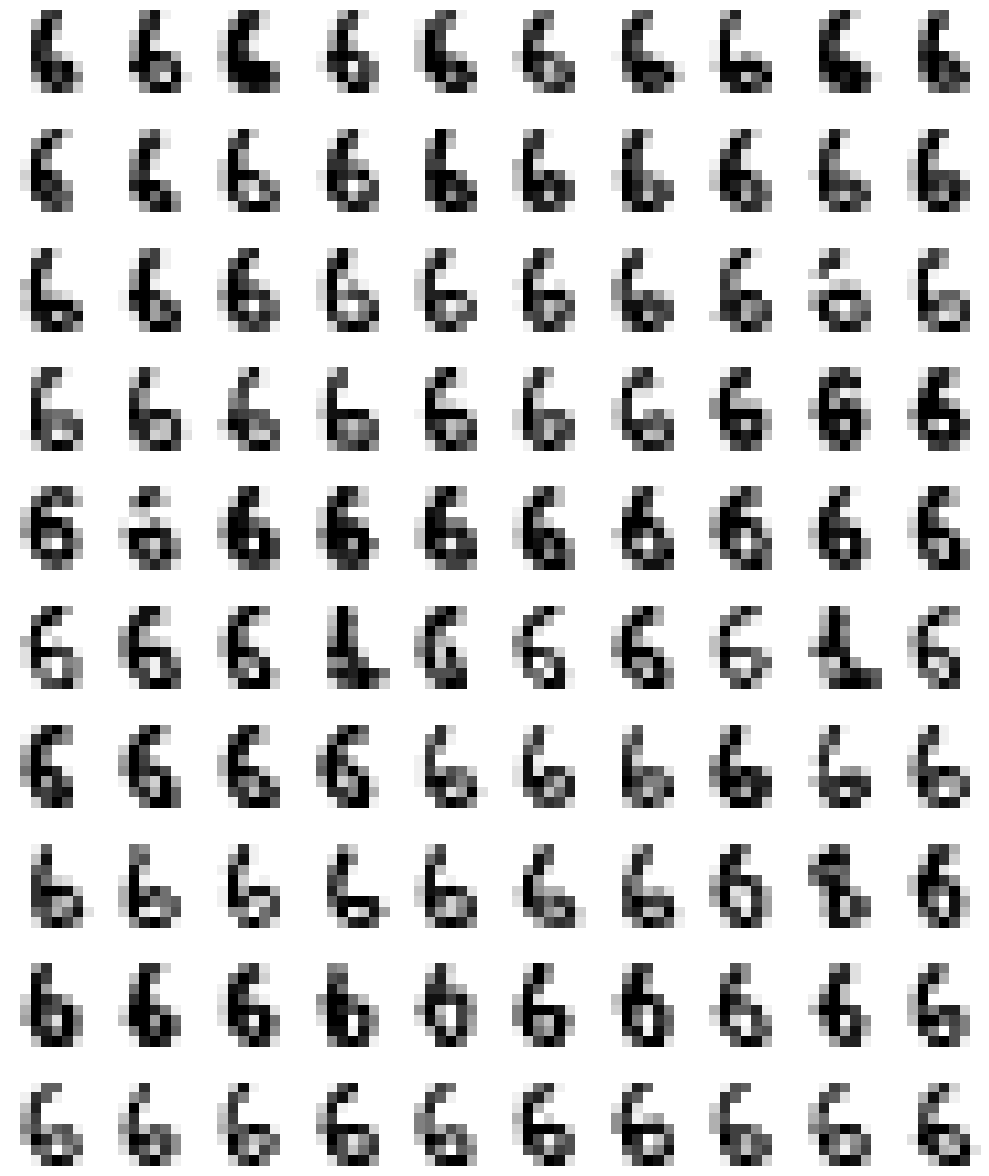

Clúster 5: 151 elementos


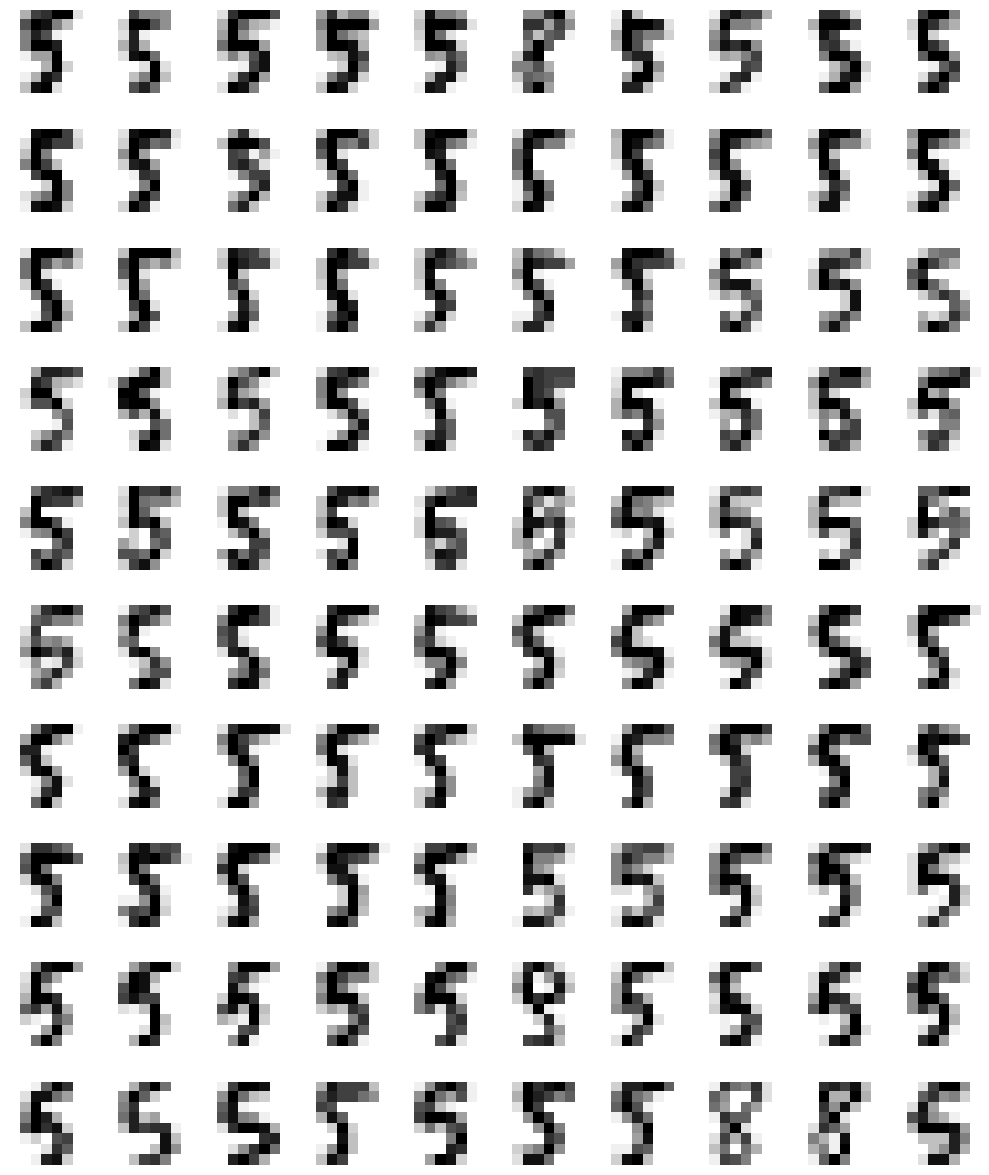

Clúster 6: 264 elementos


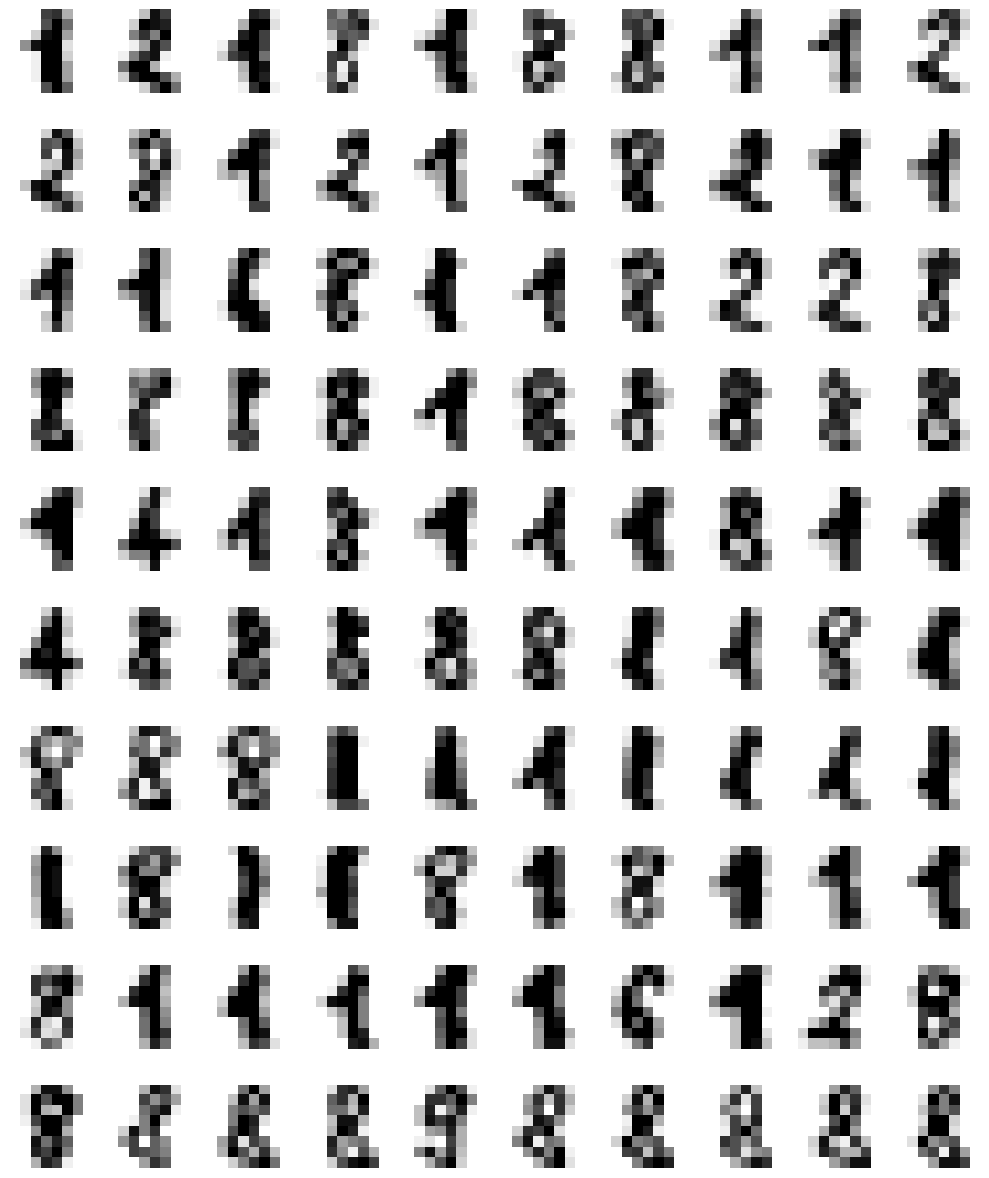

Clúster 7: 442 elementos


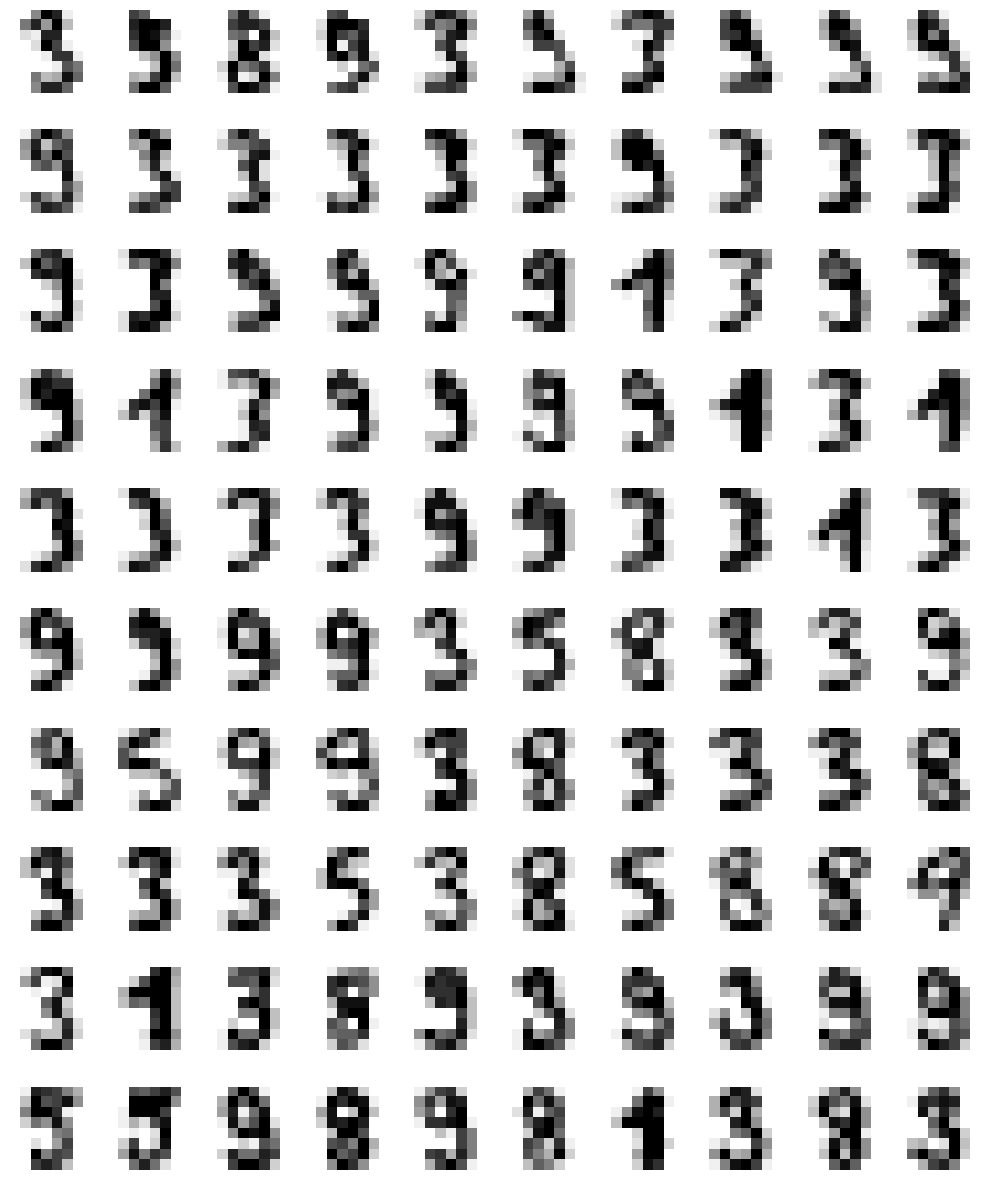


K = 8: ¿Qué números aparecen en cada clúster?
Dígito real    0    1    2    3    4    5    6    7    8    9
Clúster                                                      
0              0   25  149    3    0    0    0    0    4    0
1              0    0    4    8   10    0    0  177    8   13
2            176    0    1    0    0    0    1    0    1    0
3              2    0    0    0  169    2    0    0    0    6
4              0    2    0    0    0    2  176    0    1    0
5              0    1    0    2    0  139    0    0    5    4
6              0  131   10    7    2    0    4    2  104    4
7              0   23   13  163    0   39    0    0   51  153

Número más frecuente en cada clúster:
Clúster
0    2
1    7
2    0
3    4
4    6
5    5
6    1
7    3
dtype: int64




In [10]:
analizar_kmeans(k=8)

## Análisis para K = 6

Clúster 0: 179 elementos


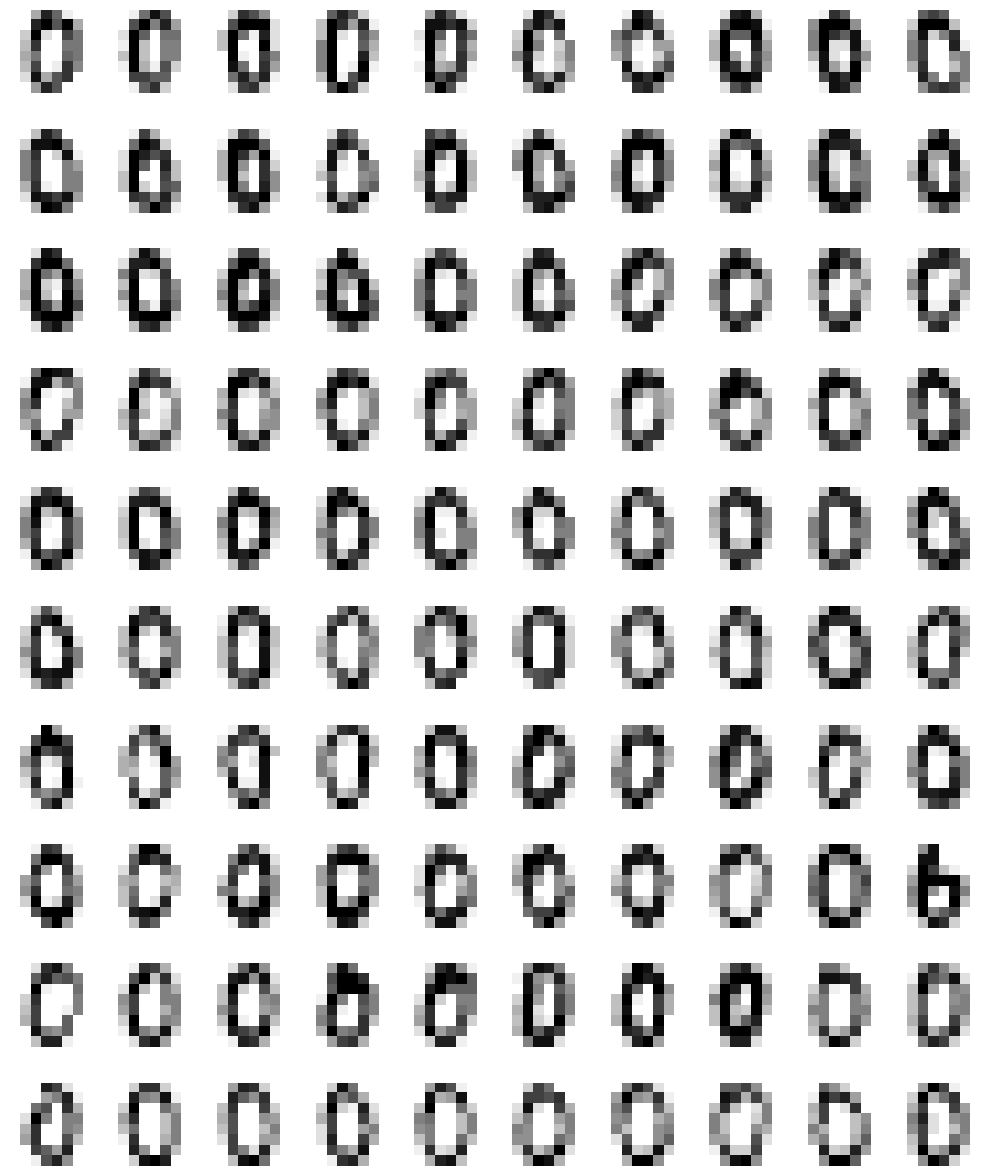

Clúster 1: 258 elementos


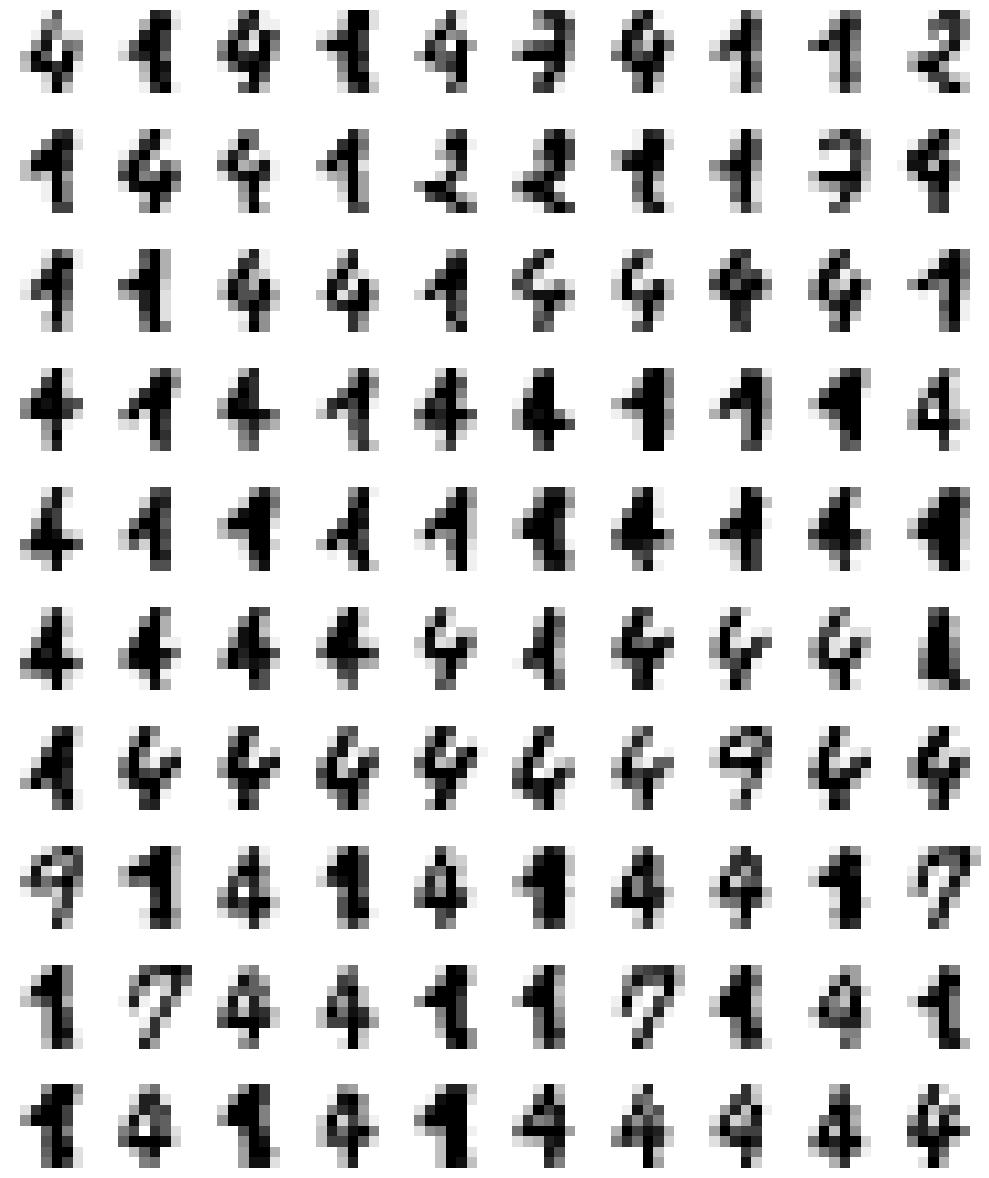

Clúster 2: 188 elementos


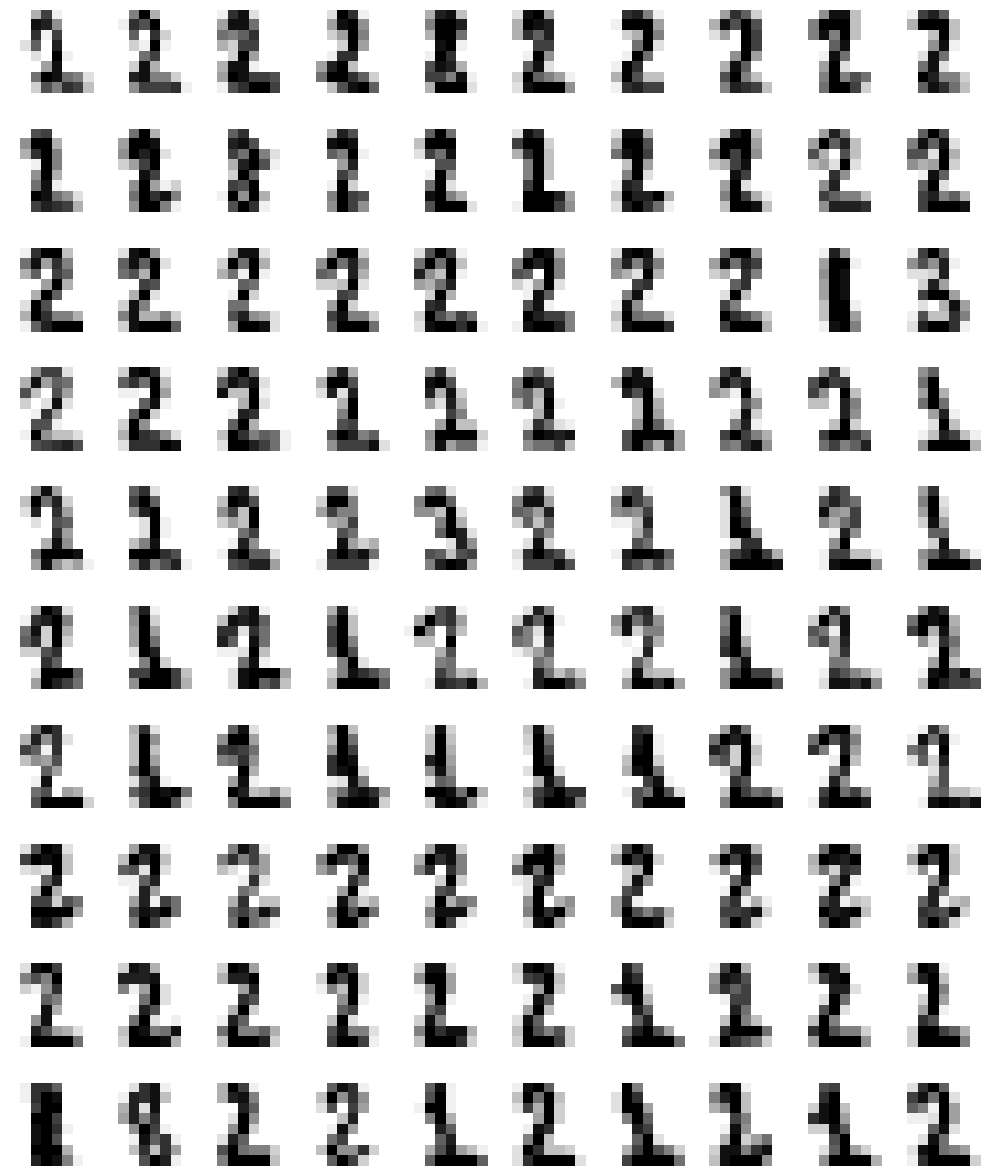

Clúster 3: 188 elementos


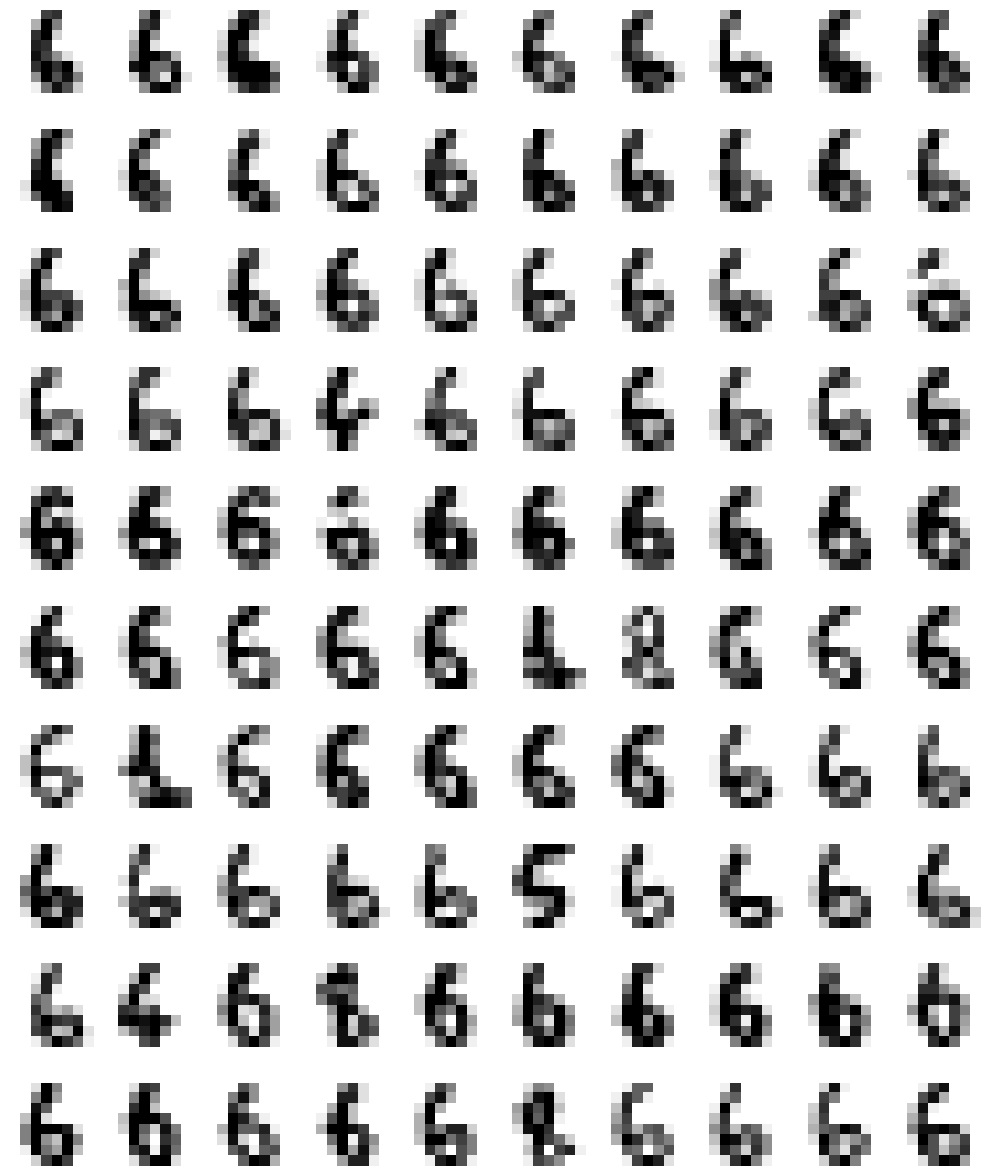

Clúster 4: 499 elementos


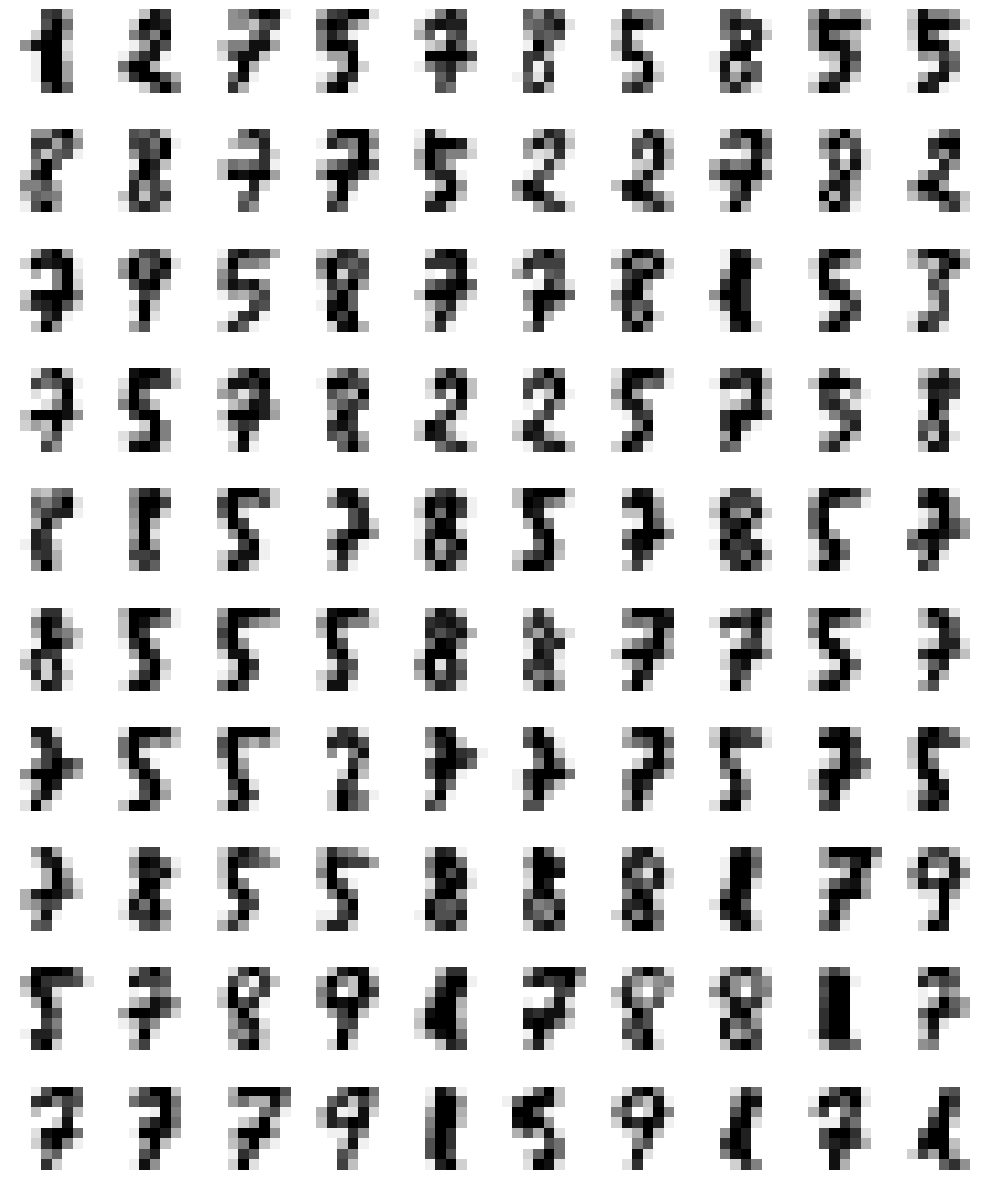

Clúster 5: 485 elementos


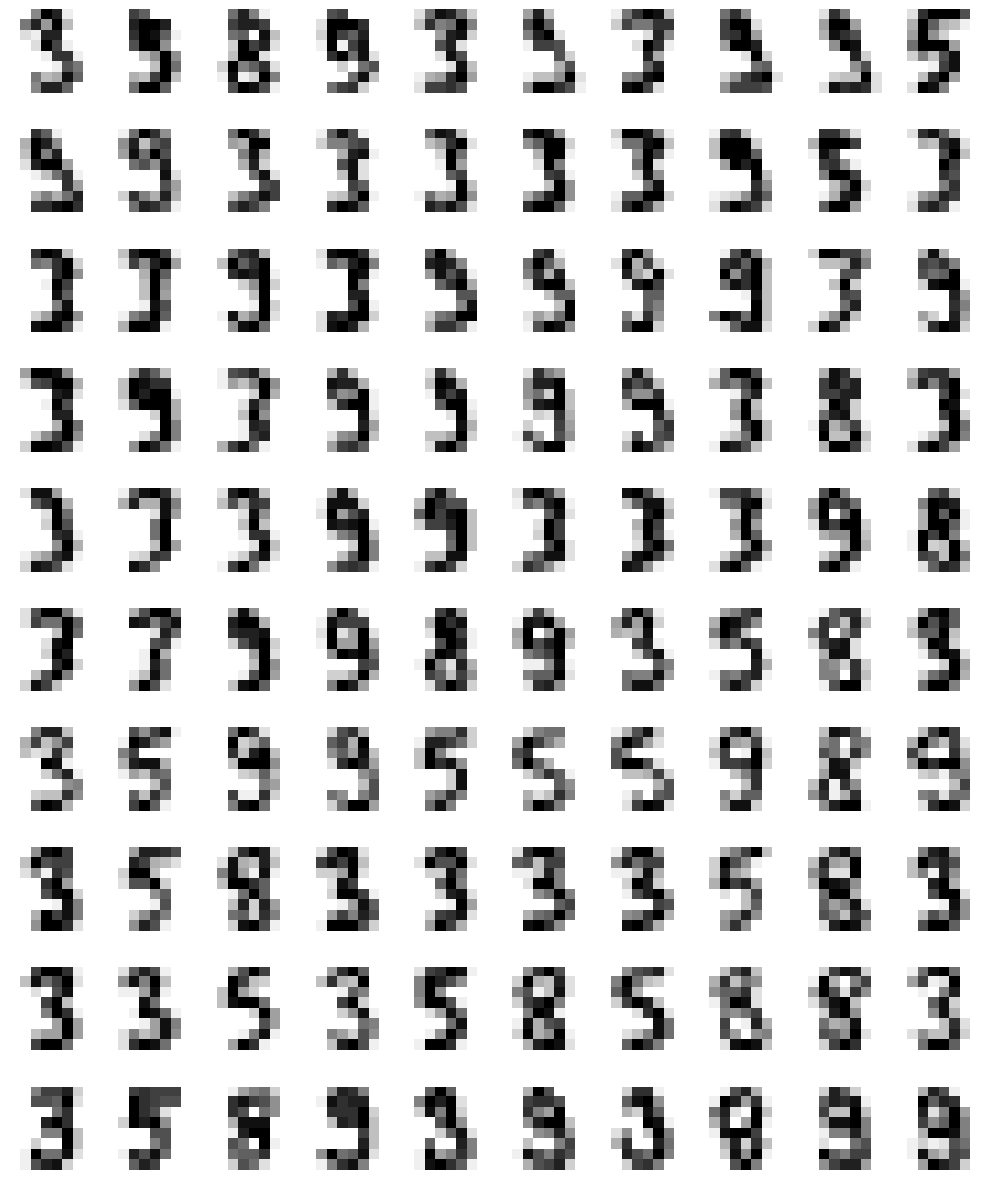


K = 6: ¿Qué números aparecen en cada clúster?
Dígito real    0   1    2    3    4   5    6    7   8    9
Clúster                                                   
0            176   0    1    0    1   0    1    0   0    0
1              2  50    3    0  164   5    1   11   3   19
2              0  30  148    2    0   0    0    0   8    0
3              0   2    0    0    2   3  178    0   3    0
4              0  92   13   14   14  88    1  168  95   14
5              0   8   12  167    0  86    0    0  65  147

Número más frecuente en cada clúster:
Clúster
0    0
1    4
2    2
3    6
4    7
5    3
dtype: int64




In [11]:
analizar_kmeans(k=6)

## Análisis para K = 4

Clúster 0: 343 elementos


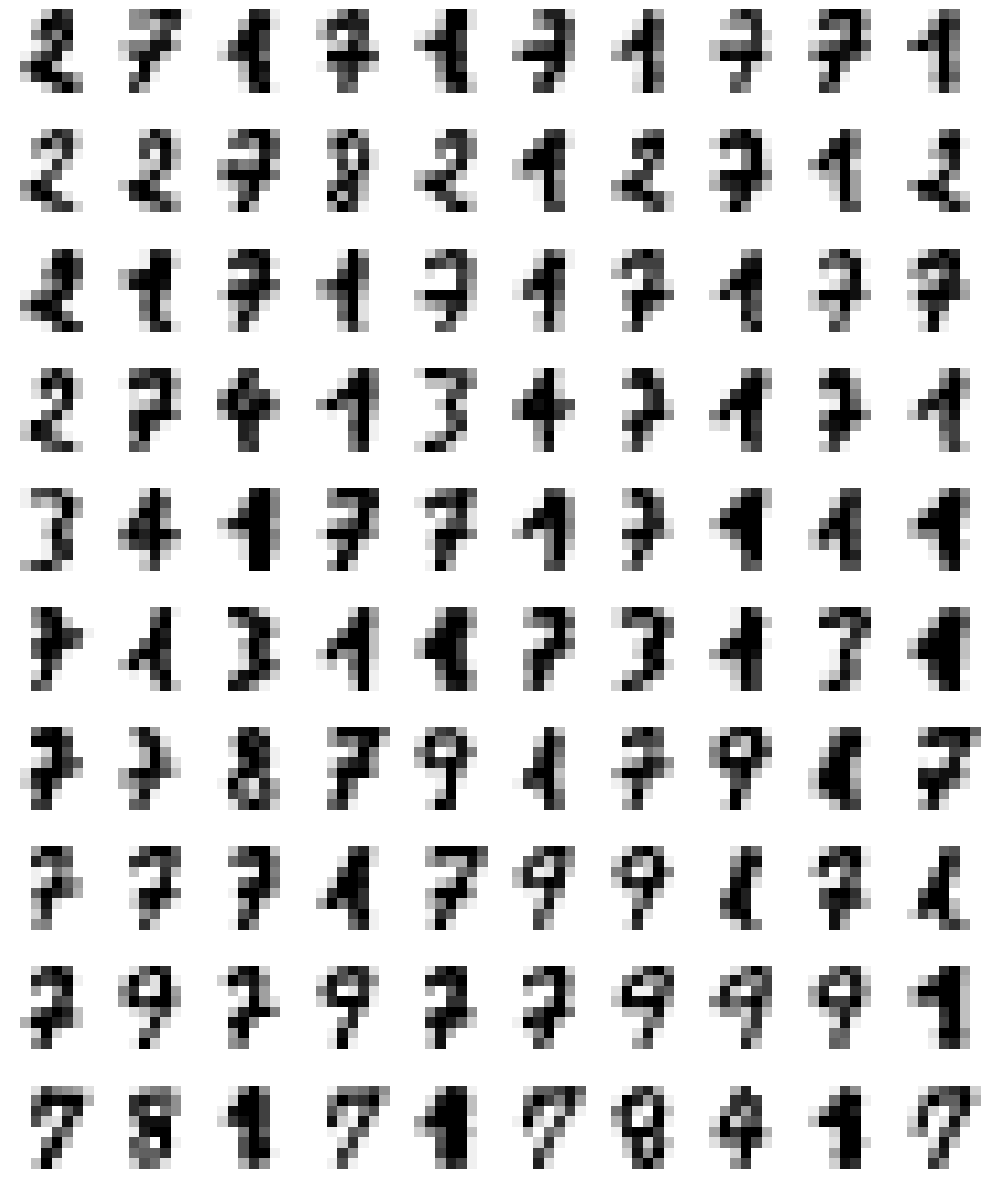

Clúster 1: 491 elementos


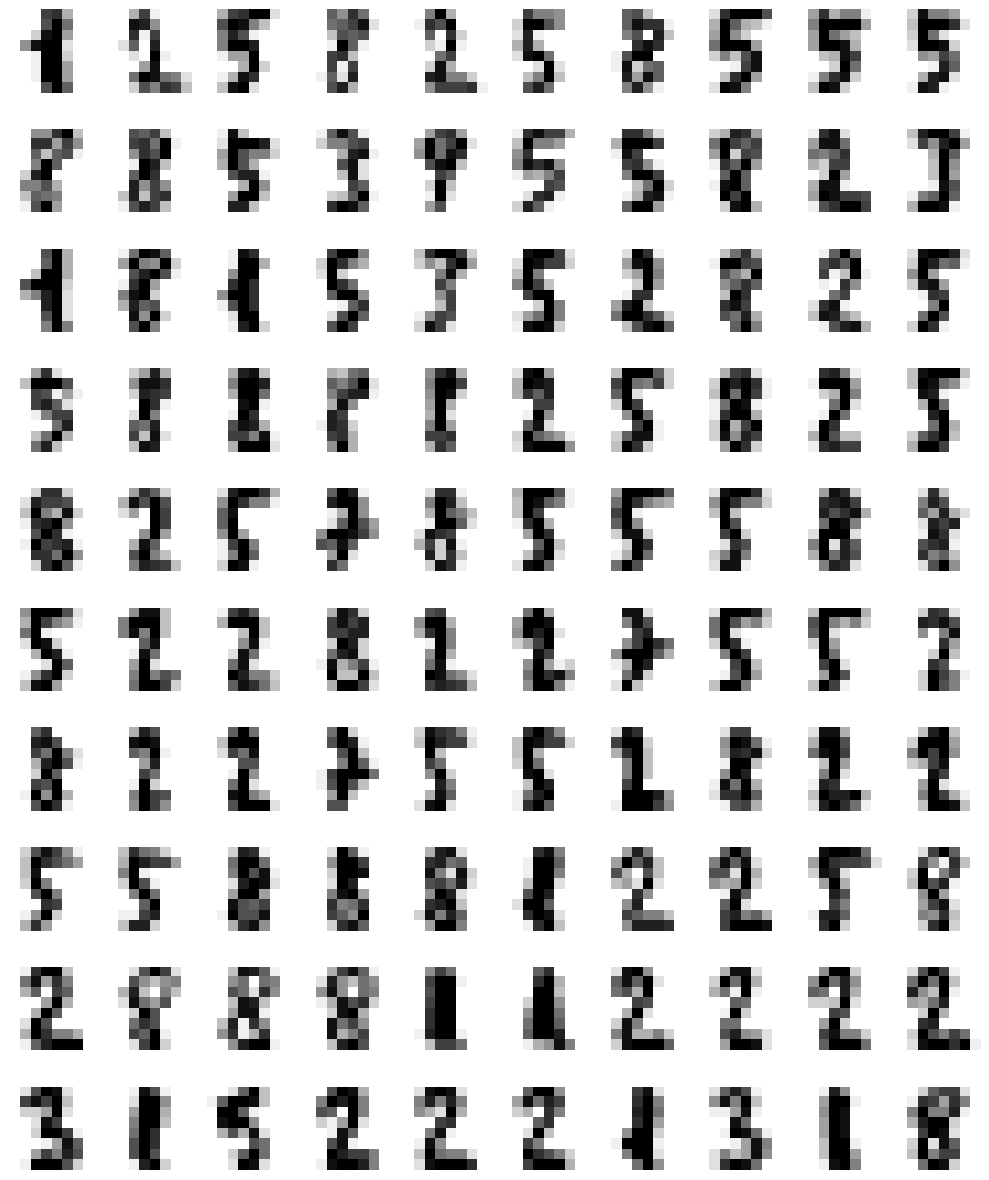

Clúster 2: 601 elementos


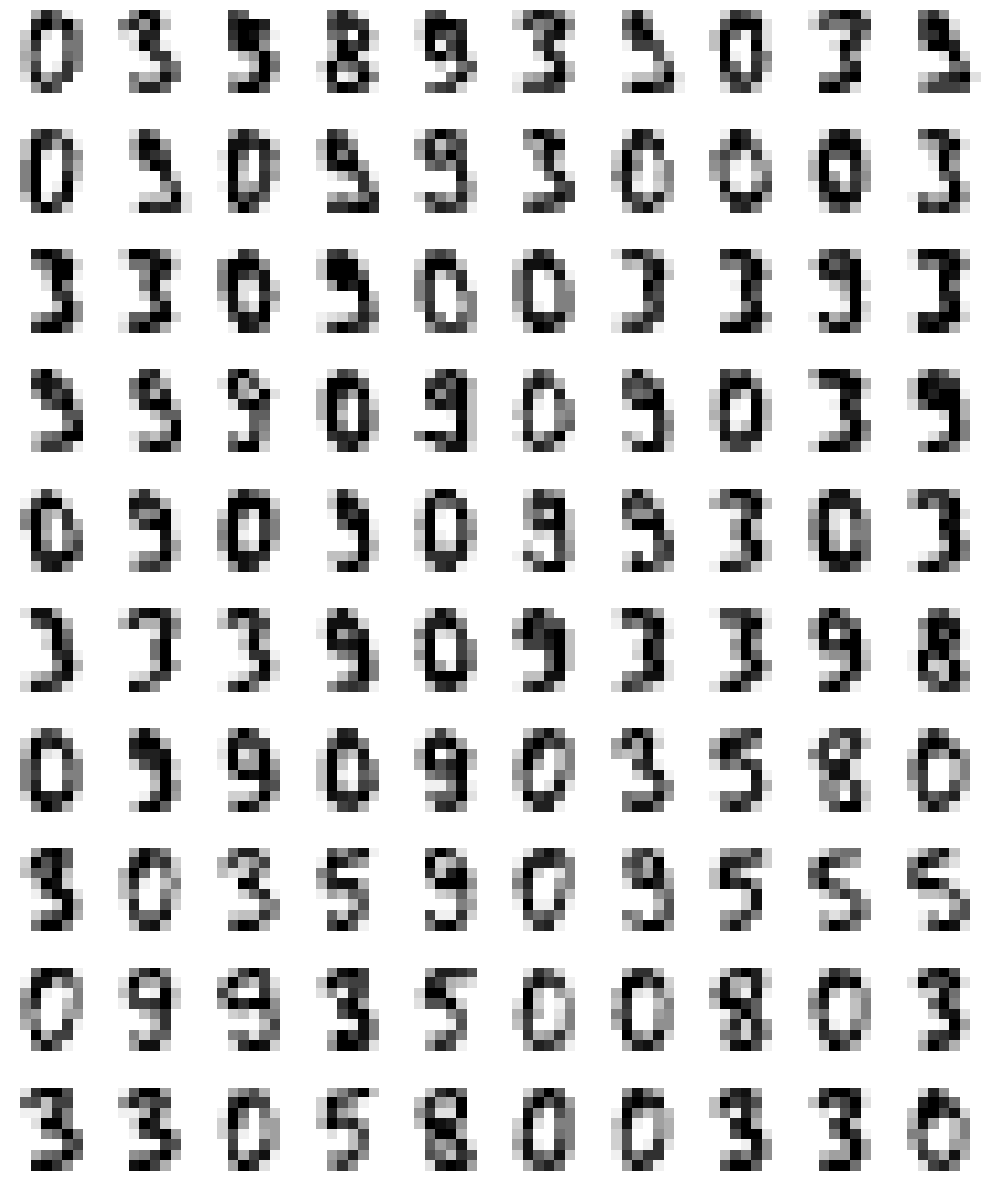

Clúster 3: 362 elementos


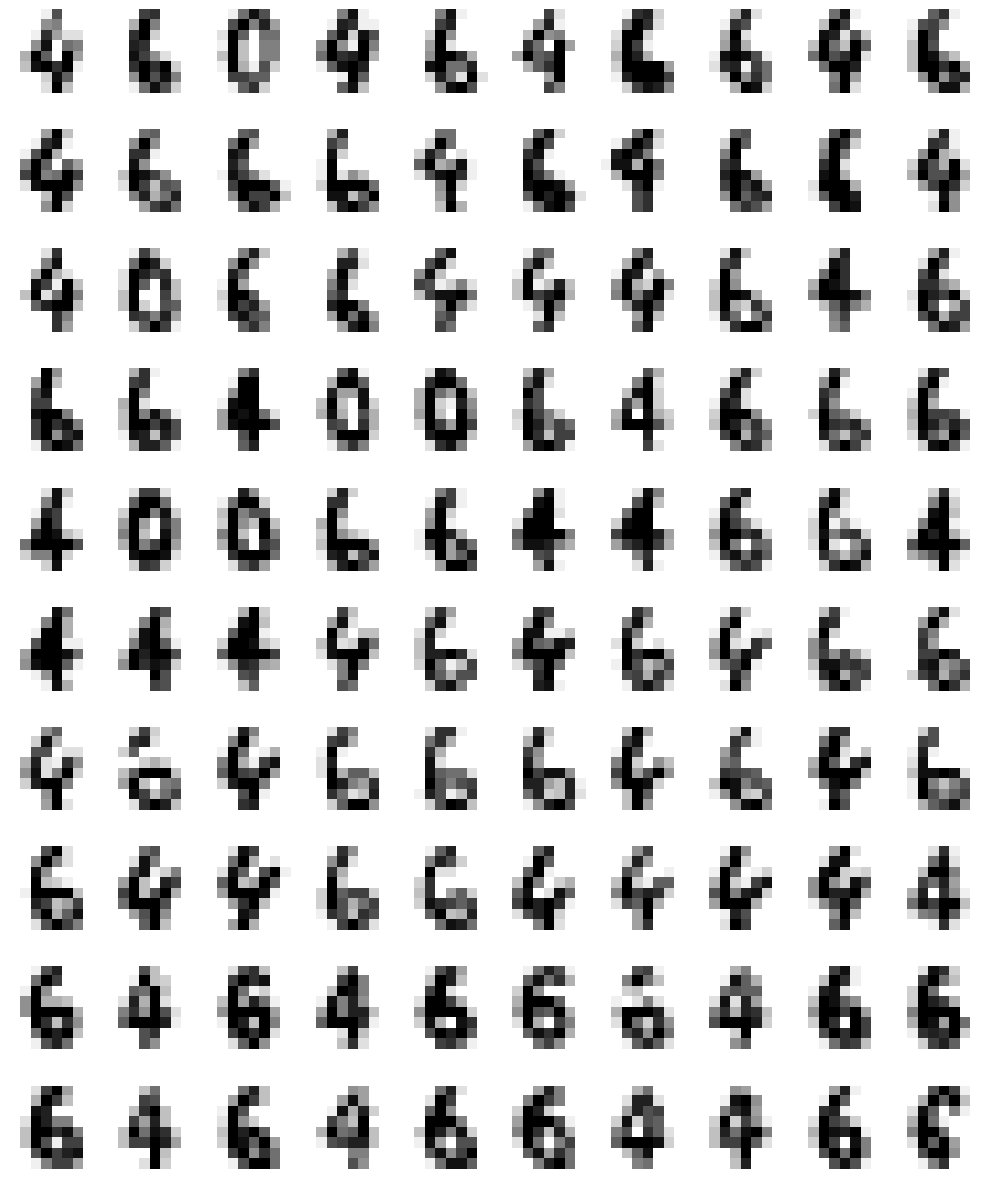


K = 4: ¿Qué números aparecen en cada clúster?
Dígito real    0    1    2    3    4   5    6    7   8    9
Clúster                                                    
0              0   64   13   15   20   5    0  158  37   31
1              0  109  151   19    3  88    0   21  96    4
2            166    7   13  149    0  80    0    0  41  145
3             12    2    0    0  158   9  181    0   0    0

Número más frecuente en cada clúster:
Clúster
0    7
1    2
2    0
3    6
dtype: int64




In [12]:
analizar_kmeans(k=4)

## Observaciones finales

- Con **K=10**, algunos dígitos (p.ej. 0 y 6) forman clústeres casi puros, pero otros (3, 8, 9) se mezclan.
- Al reducir el número de clústeres, los dígitos con trazos similares (1‑9, 3‑8) tienden a agruparse.
- La inversión de colores ayudó a que K‑Means encuentre mejor las formas (fondo oscuro, dígito claro).